# Homework: PyTorch Multi-Layer Perceptron

This is a set of homework questions based on the `SimpleDNN.ipynb` tutorial, which will ask you to perform some experimentation and draw some insights about neural networks. We will use the same datasets as before, so make sure you still have those! It may also be beneficial to refer to that notebook if you're ever confused about the physics task at hand.

As you work, feel free to insert cells into this notebook as needed. Please keep the overall structure (order of the problems, etc) consistent, but don't feel overly bound by the scaffolding laid out!

To get started, we'll import the same tools we've used before.

In [1]:
import os
from itertools import cycle
import numpy as np
import vector
import torch
from matplotlib import pyplot as plt

print("Is there an available GPU? ", end="")
if torch.cuda.is_available():
    device = "cuda:0"
    print("Yes")    
else:
    device = "cpu"
    print("No")

Is there an available GPU? Yes


To start, you should load in the datasets (and build `DataLoader`s) and re-create the model architecture you built from the tutorial. While I have no doubt you'll reference that code, try to make sure you're actually typing out at least a significant portion of it here. I've found that copy/pasting is often the enemy of knowledge retention!

In [2]:
train_dataset = torch.load("data/ttbar_dilepton_collide_train.pt", weights_only=False)
valid_dataset = torch.load("data/ttbar_dilepton_collide_valid.pt", weights_only=False)

batch_size = 2048
valid_batch_size = 16384

if torch.cuda.is_available():
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)
    valid_dataloader = torch.utils.data.DataLoader(valid_dataset, batch_size=valid_batch_size, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)
else:
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    valid_dataloader = torch.utils.data.DataLoader(valid_dataset, batch_size=valid_batch_size, shuffle=True, drop_last=True)

valid_dataloader_iterator = cycle(valid_dataloader)


In [3]:
os.makedirs("./models/", exist_ok=True)

class MLPModel(torch.nn.Module):
    def __init__(self, d_input, n_layers, d_layers, d_output, dropout=0.0):
        super().__init__() # IMPORTANT: This allows the `torch.nn.Module` to initialize and prepare to register our model blocks

        # This builds up the layers we want in our network
        layers = [torch.nn.Linear(d_input, d_layers), torch.nn.ReLU()]
        for idx in range(n_layers-1):
            layers.append(torch.nn.Linear(d_layers, d_layers))
            layers.append(torch.nn.ReLU())
            if (dropout > 0.0):
                layers.append(torch.nn.Dropout(dropout))
        layers.append(torch.nn.Linear(d_layers, d_output))

        self.stack = torch.nn.Sequential(*layers) # Registers our layers as a single feedforward block

    def forward(self, inputs):
        return self.stack(inputs)

### Problem 1

Now that you have a model class defined and some datasets, you should implement training! Here, we're going to do things a little differently than in the tutorial: you'll be wrapping all of the training process up neatly into a function! This will allow you to run multiple trainings easily within the notebook, which you'll be doing in later problems. Your function should accept as parameters:
- an instance of your model class (the model to train)
- an optimizer (instance of a class in the [`torch.optim`](https://docs.pytorch.org/docs/stable/optim.html) module)
- a loss function (can be an instance of any subclass of `torch.nn.Module`, though will most likely be one of the losses that PyTorch implements)
- a number of epochs to train
- anything else you feel you'll need (or just want to include)

It should then return the trained model.

A couple of pointers for the design of this function:
- Try to make it as self-contained as possible. This will likely involve adding additional parameters beyond the four mentioned above (what else did we need to know in order to set up our training?), but will pay off in the long run, as you can easily run trainings with a variety of configurations.
- This function will likely spend more than a minute running when called (it takes time to train)! During that time, it might be nice to get some feedback that things are running as expected. Feel free to add `print` statements (or use other tools) to monitor your training progress!

A simple signature has been included for you. When you finish, train a model! It might be a good idea to save them with `torch.jit.script(my_model).save(file_name)`. You can then load all your models and compare them very easily, with `my_model = torch.jit.load(file_name)`.

- First, Lets define the function

In [4]:
def train_my_model(model, optimizer, loss_fn, train_dataloader, valid_dataloader_iterator, model_name, epochs=5):
    
    # Here we want to store the losses 
    train_loss = []
    valid_loss = []
    train_error = []
    valid_error =  []
    
    grad_clip_value = 80.0

    # Print the number the parameters just to check if it is looks ok.
    print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
    
    for epoch in range(1, epochs+1):
        if (epoch)  % 10 == 0:
            print(f"Starting epoch {epoch}.")
        model.train()
        for batch, (jets, leptons, met, mask, target) in enumerate(train_dataloader):
            # print(jets)
            optimizer.zero_grad()
            relative_error = 0
            relative_error_abs = 0
            mean_rel_error = 0
            
            jets = jets.reshape([-1, 40])
            leptons = leptons.reshape([-1, 10])
            met = met.reshape([-1, 2])
            
            inputs = torch.concat([jets, leptons, met], dim=-1).to(device)
            target = target.reshape([-1, 8]).to(device)

            
            pred = model(inputs) 
    
            loss = loss_fn(pred, target)


            error = (target.detach().to("cpu").numpy() - pred.detach().to("cpu").numpy()) 
            error_abs = np.abs(error)
            mean_error = np.mean(error_abs)
            
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_value) # gradient clipping
            optimizer.step()
    

            train_loss_number = loss.detach().to("cpu").item()
            train_loss.append(train_loss_number)
            train_error.append(mean_error)
            
            
    
        model.eval()
        with torch.no_grad():

            relative_error = 0
            relative_error_abs = 0
            mean_rel_error = 0
            
            jets_valid, leptons_valid, met_valid, pad_mask_valid, target_valid = next(valid_dataloader_iterator)
            jets_valid = jets_valid.reshape([-1, 40])
            leptons_valid = leptons_valid.reshape([-1, 10])
            met_valid = met_valid.reshape([-1, 2])
            
            inputs_valid = torch.concat([jets_valid, leptons_valid, met_valid], dim=-1).to(device)
            
            target_valid = target_valid.reshape([-1, 8]).to(device)

           
    
            pred_valid = model(inputs_valid)
            loss_valid = loss_fn(pred_valid, target_valid)

            error = (target_valid.detach().to("cpu").numpy() - pred_valid.detach().to("cpu").numpy())
            error_abs = np.abs(error)
            mean_error = np.mean(error_abs)
            
    
            valid_loss_number = loss_valid.detach().to('cpu').item()
            valid_loss.append(valid_loss_number)
            valid_error.append(mean_error)
        
    torch.jit.script(model).save("./models/model_" + model_name + ".pt")
    print("Done with the training.")
        
    return model, train_loss, valid_loss, train_error, valid_error

Then we create an instance of our model class

In [5]:
model_params = {
    "d_input": 52,
    "n_layers": 4,
    "d_layers": 192,
    "d_output": 8,
    "dropout": 0.1,
}
model = MLPModel(**model_params)
model = model.to(device)
learning_rate = 1.0e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")

Finally, we can call our function and run the training

In [6]:
_,_,_,_,_ = train_my_model(model, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "test", epochs=15)

Trainable parameters: 122888
Starting epoch 10.
Done with the training.


### Problem 2: Model Size

Now that we can create and train a variety of models easily, let's investigate a major aspect (and sometimes pain point) in machine learning: how does the performance of our model vary as its size changes? Train at least 4 different models (for at least 5 epochs each) and examine their performance on the validation (or testing) dataset. Which one performed the best? Write down your observations in markdown cells as you go, and try to compare performance directly (perhaps even in a plot?) among the different trainings you ran.

In [7]:
# Lets define dictionaries to stores the losses and do the plots later.
loss_train_map = {}
loss_validation_map = {}
error_train_map = {}
error_validation_map = {}

We will store the values of the losses for different models. Lets define a function to plot them after we have it.

In [8]:
def draw_losses(variables, labels, use_loss = True,  y_range= [-1,-1]):

    fig, (ax_train, ax_valid) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    colors = ["blue", "orange", "green", "purple"]

    for i, variable in enumerate(variables):
    
        if use_loss:
            validation_list = loss_validation_map[variable]
            train_list = loss_train_map[variable]
        else:
            validation_list = error_validation_map[variable]
            train_list = error_train_map[variable]
        
        epochs_list = np.arange(1, len(validation_list)+1)
        steps_list = np.linspace(0, len(validation_list), len(train_list))

        ax_train.plot(steps_list, train_list, label=labels[i], color=colors[i])
        ax_valid.plot(epochs_list, validation_list, label=labels[i], color=colors[i])
        
    
    ax_train.set_title("Training ")
    ax_train.set_xlabel("Epoch")
    
    if use_loss:
        ax_train.set_ylabel("Loss")
    else:
        ax_train.set_ylabel("Relative error")
    ax_train.legend()

    ax_valid.set_title("Validation")
    ax_valid.set_xlabel("Epoch")
    ax_valid.legend()

    if y_range[0] != -1:
        ax_train.set_ylim(*y_range)
        ax_valid.set_ylim(*y_range) 

    
    plt.tight_layout()
    plt.show()
    plt.close()

We have two different ways to increase the model size. We can increase the number of layers or the number of neurons per layer. Lets instanciate models with 2,4,6,8 layers and with 96, 192, 288, 384 neurons per layer. Lets train all of them a then compare out results

In [9]:
%%time

model_nl2 = MLPModel(d_input=52, n_layers= 2, d_layers=192, d_output=8, dropout= 0.1)
model_nl2 = model_nl2.to(device)


optimizer = torch.optim.Adam(model_nl2.parameters(), lr=learning_rate, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["nl-2"], loss_validation_map["nl-2"],_,_ = train_my_model(model_nl2, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "nl-2", epochs=30)

Trainable parameters: 48776
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 8.21 s, sys: 3.46 s, total: 11.7 s
Wall time: 55.7 s


In [10]:
%%time
model_nl4 = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_nl4 = model_nl4.to(device)

optimizer = torch.optim.Adam(model_nl4.parameters(), lr=learning_rate, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["nl-4"], loss_validation_map["nl-4"], error_train_map["nl-4"], error_validation_map["nl-4"] = train_my_model(model_nl4, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "nl-4", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 8.72 s, sys: 3.3 s, total: 12 s
Wall time: 48.8 s


In [11]:
%%time
model_nl6 = MLPModel(d_input=52, n_layers= 6, d_layers=192, d_output=8, dropout= 0.1)
model_nl6 = model_nl6.to(device)


optimizer = torch.optim.Adam(model_nl6.parameters(), lr=learning_rate, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["nl-6"], loss_validation_map["nl-6"],_,_ = train_my_model(model_nl6, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "nl-6", epochs=30)

Trainable parameters: 197000
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 9.85 s, sys: 3.48 s, total: 13.3 s
Wall time: 49.5 s


In [12]:
%%time

model_nl8 = MLPModel(d_input=52, n_layers= 8, d_layers=192, d_output=8, dropout= 0.1)
model_nl8 = model_nl8.to(device)
# print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

optimizer = torch.optim.Adam(model_nl8.parameters(), lr=learning_rate, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["nl-8"], loss_validation_map["nl-8"],_,_ = train_my_model(model_nl8, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "nl-8", epochs=30)

Trainable parameters: 271112
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 11.4 s, sys: 3.48 s, total: 14.9 s
Wall time: 54.5 s


In [13]:
%%time

model_dl96 = MLPModel(d_input=52, n_layers= 4, d_layers=96, d_output=8, dropout= 0.1)
model_dl96 = model_dl96.to(device)

optimizer = torch.optim.Adam(model_dl96.parameters(), lr=learning_rate, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["dl96"], loss_validation_map["dl96"],_,_ = train_my_model(model_dl96, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "dl96", epochs=30)

Trainable parameters: 33800
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 8.97 s, sys: 3.56 s, total: 12.5 s
Wall time: 51.1 s


In [14]:
%%time

model_dl288 = MLPModel(d_input=52, n_layers= 4, d_layers=288, d_output=8, dropout= 0.1)
model_dl288 = model_dl288.to(device)

optimizer = torch.optim.Adam(model_dl288.parameters(), lr=learning_rate, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["dl288"], loss_validation_map["dl288"],_,_ = train_my_model(model_dl288, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "dl288", epochs=30)

Trainable parameters: 267272
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 9.03 s, sys: 3.64 s, total: 12.7 s
Wall time: 50.7 s


In [15]:
%%time

model_dl384 = MLPModel(d_input=52, n_layers= 4, d_layers=384, d_output=8, dropout= 0.1)
model_dl384 = model_dl384.to(device)

optimizer = torch.optim.Adam(model_dl384.parameters(), lr=learning_rate, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["dl384"], loss_validation_map["dl384"],_,_ = train_my_model(model_dl384, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "dl384", epochs=30)

Trainable parameters: 466952
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 9.49 s, sys: 3.88 s, total: 13.4 s
Wall time: 51 s


Now we can use our function to plot them and compare

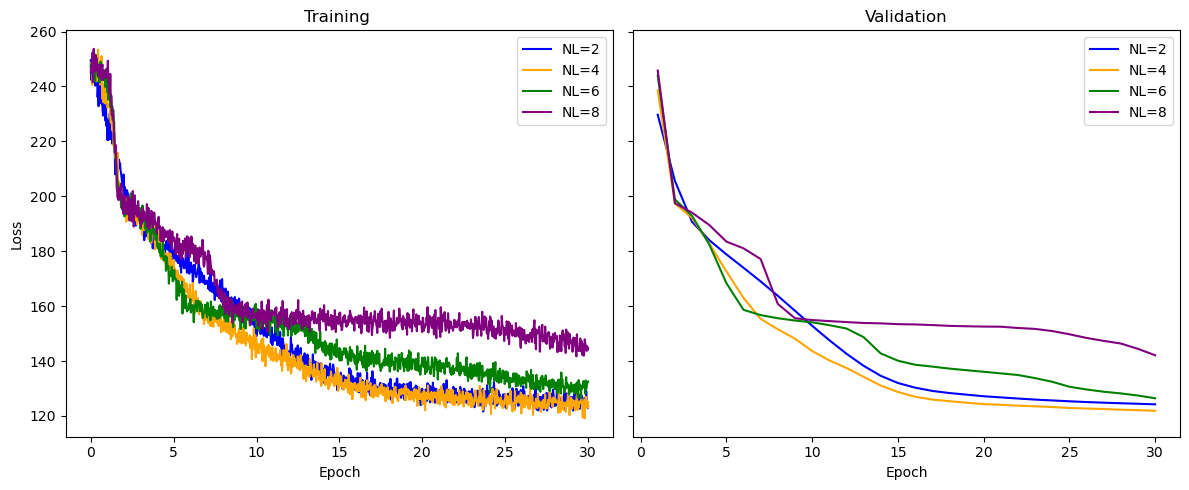

In [16]:
draw_losses(["nl-2", "nl-4", "nl-6", "nl-8"], ["NL=2", "NL=4", "NL=6", "NL=8"])

We can see that the optimal value is 4 layers. We see that increasing the number of layers does not necessarily improve the prediction.

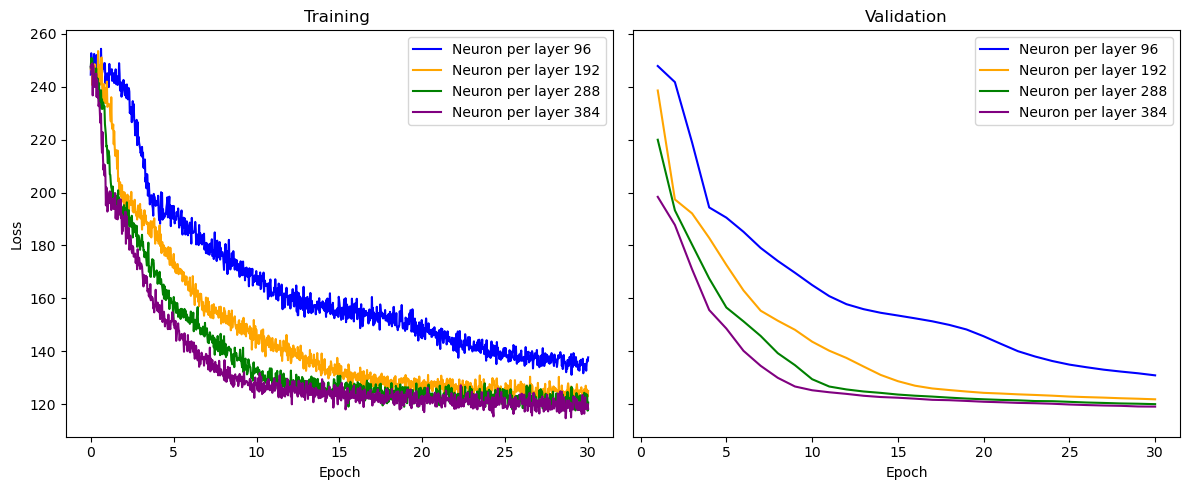

In [17]:
draw_losses(["dl96", "nl-4", "dl288", "dl384"], ["Neuron per layer 96", "Neuron per layer 192", "Neuron per layer 288", "Neuron per layer 384"])

We can se that in our case increse the number or layers improve the training. Although, with enought epochs all the model with more than 96 neurons reach roughly the same loss.

### Problem 3: Our Input Data

To understand our problem a little better, let's look a bit more closely at what we're giving the model.

#### Part 3a: Taking a Look

Plot histograms of several of the observables that serve as inputs to our model. You should at least plot the $p_x$, $p_z$, and $E$ of the _first jet_, _lepton_, and _targets (top quarks/antiquarks)_, and the $p_x$ and $p_y$ of the missing transverse energy. What do you see? Do all the variables lie in about the same range, or are their domains different? What about their distributions? Summarize your findings.

First define a function to do the plots. I am assuming that the energies unit is $[GeV]$ and the momentum unit is $[GeV/c]$

In [18]:
def draw_4momentum_from_data(dataset, tensor, particles, fix_axis_limits= False, is_met=False):

    # tensor: int to select which tensor of the dataset we want to plot. 1: jets, 2: leptons, 3: Met, 4: - 5) top quarks(target) 
    # particle: int list to select which particles we want to plot. the posible values are Jets 1-8, leptions 1-2, Met 1, mask - , target 2
    
    n_plots = 4
    width = 24
    if is_met:
        n_plots= 2
        width = 12
    fig, axs = plt.subplots(1, n_plots, figsize=(width, 5), sharey=True)
    colors = ["blue", "orange", "purple", "red"]
    for particle in particles:
        px_array = np.array([])
        py_array = np.array([])
        if not is_met:
            pz_array = np.array([])
            E_array = np.array([])
        # for event in range(len(dataset)):
        # px_array = np.append(px_array, dataset[event][tensor][particle][0])
        # py_array = np.append(py_array, dataset[event][tensor][particle][1])
        px_array = dataset.tensors[tensor].numpy()[:, particle, 0]
        py_array = dataset.tensors[tensor].numpy()[:, particle, 1]
        if not is_met:
            # pz_array = np.append(pz_array, dataset[event][tensor][particle][2])
            # E_array = np.append(E_array, dataset[event][tensor][particle][3])

            pz_array = dataset.tensors[tensor].numpy()[:, particle, 2]
            E_array = dataset.tensors[tensor].numpy()[:, particle, 3]
    
        
        
        axs[0].hist(px_array, bins=30, histtype="step", linewidth=1.5, color=colors[particle], label= "Particle "+ str(particle + 1))
        axs[1].hist(py_array, bins=30, histtype="step", linewidth=1.5, color=colors[particle])
        if not is_met:
            axs[2].hist(pz_array, bins=30, histtype="step", linewidth=1.5, color=colors[particle])
            axs[3].hist(E_array, bins=30, histtype="step", linewidth=1.5, color=colors[particle])
    
    axs[0].set_title("Px")
    axs[0].set_xlabel("Px [GeV/c]")
    axs[1].set_title("Py")
    axs[1].set_xlabel("Py [GeV/c]")
    if fix_axis_limits:
        axs[0].set_xlim(-11, 11)
        axs[1].set_xlim(-11, 11)
    if not is_met:
        axs[2].set_title("Pz")
        axs[2].set_xlabel("Pz [GeV/c]")
        axs[3].set_title("Energy")
        axs[3].set_xlabel("E [GeV]")
        axs[0].legend()
        if fix_axis_limits:
            axs[2].set_xlim(-11, 11)
            axs[3].set_xlim(-3, 12)
    plt.show()

    
   
        

--------- 2 leading Jets -----------


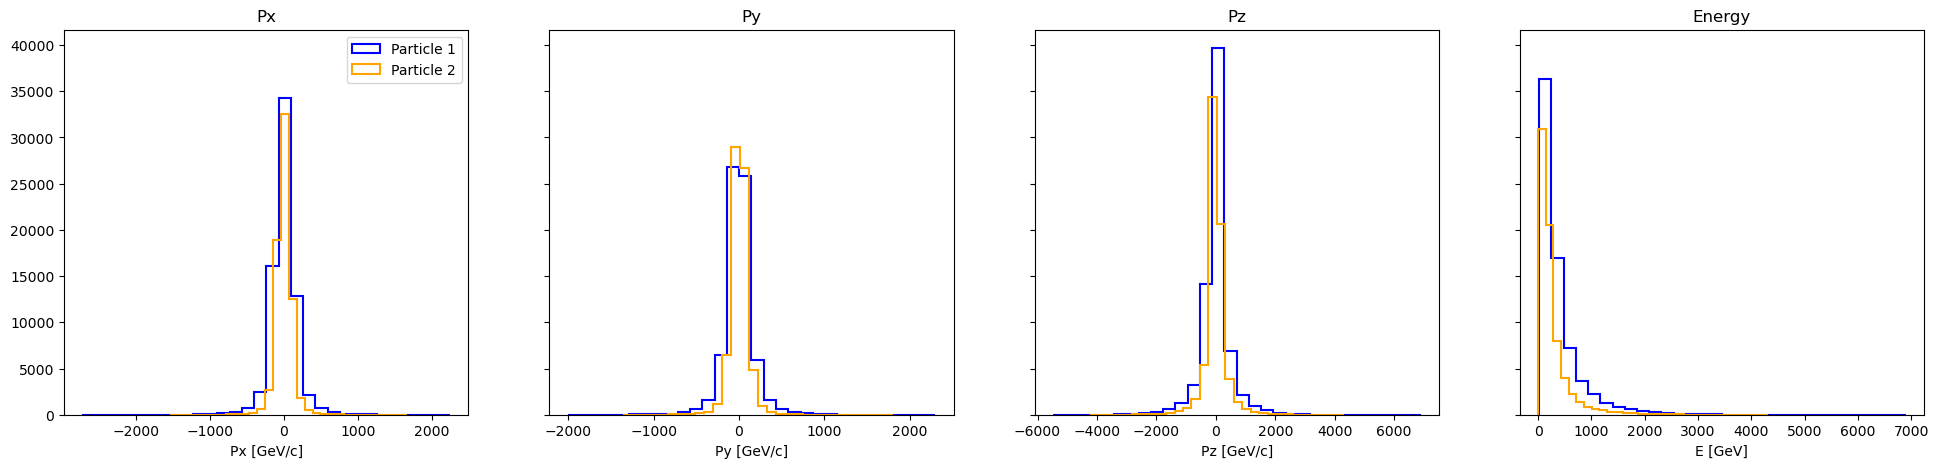

In [19]:
print("--------- 2 leading Jets -----------")
draw_4momentum_from_data(train_dataset, 0, [0,1])

--------- 2 Leptons  -----------


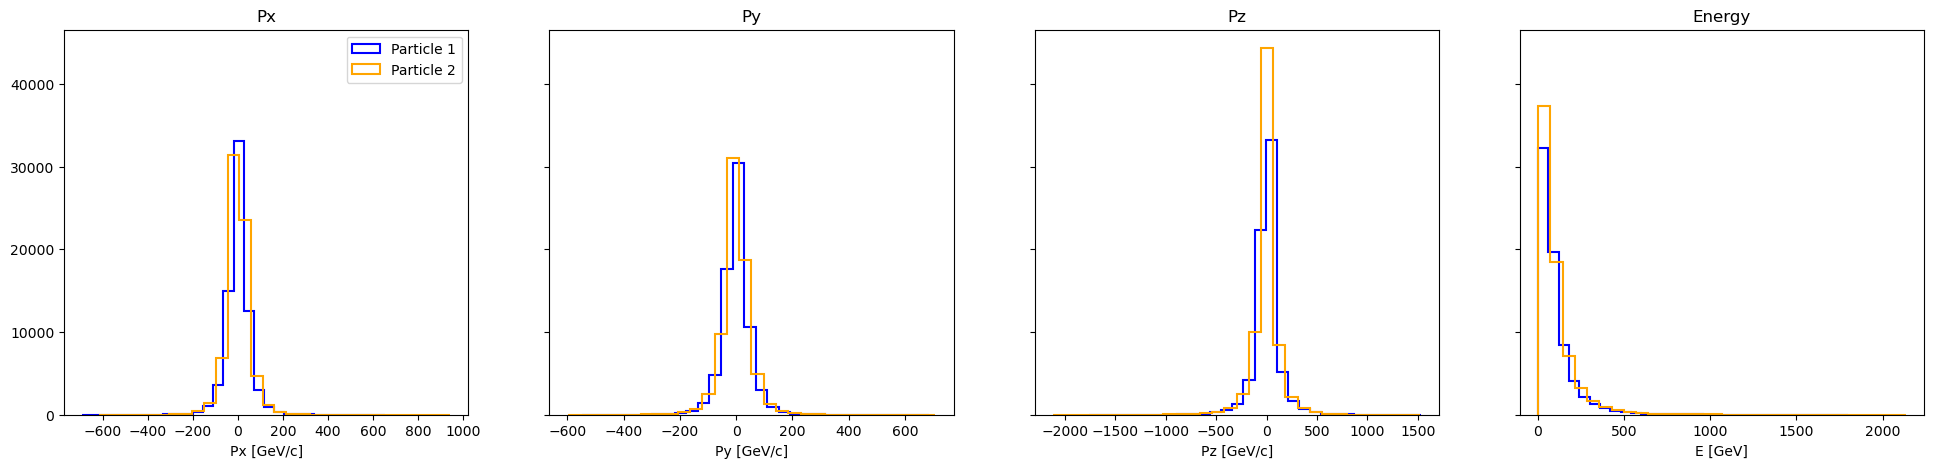

In [20]:
print("--------- 2 Leptons  -----------")
draw_4momentum_from_data(train_dataset, 1, [0,1])

--------- 2 Tops quarks  -----------


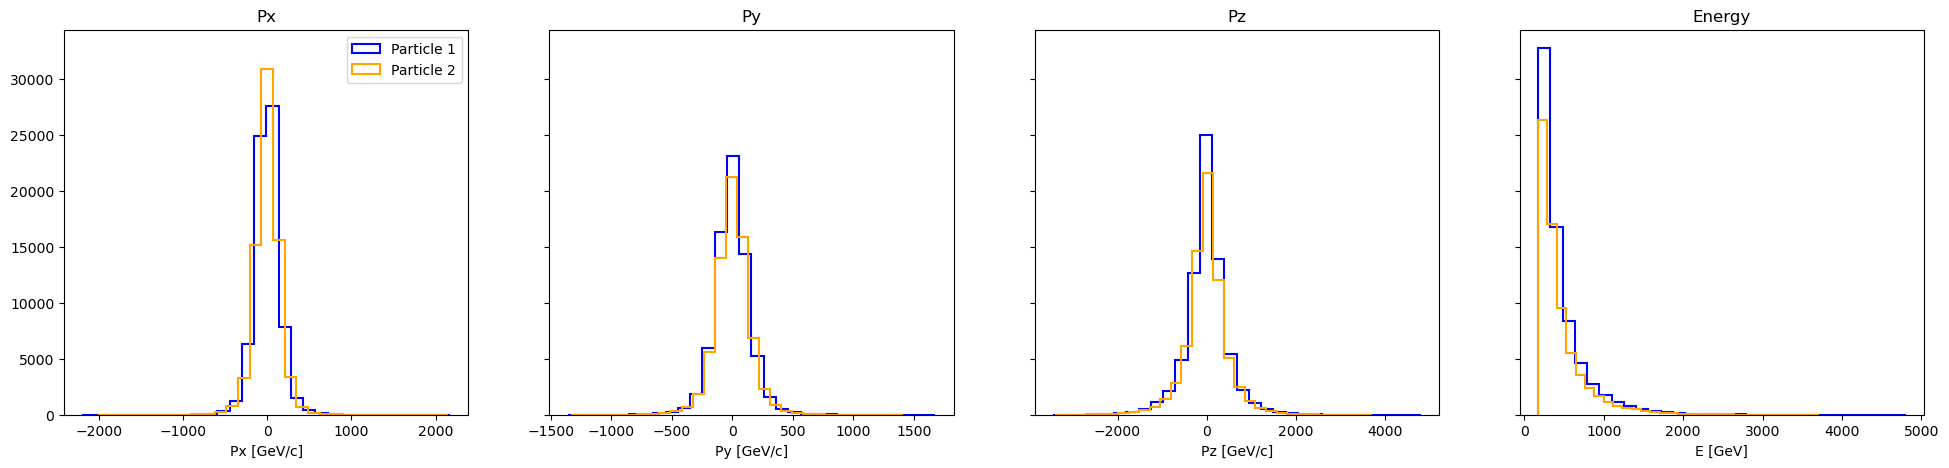

In [21]:
print("--------- 2 Tops quarks  -----------")
draw_4momentum_from_data(train_dataset, 4, [0,1])

--------- MET  -----------


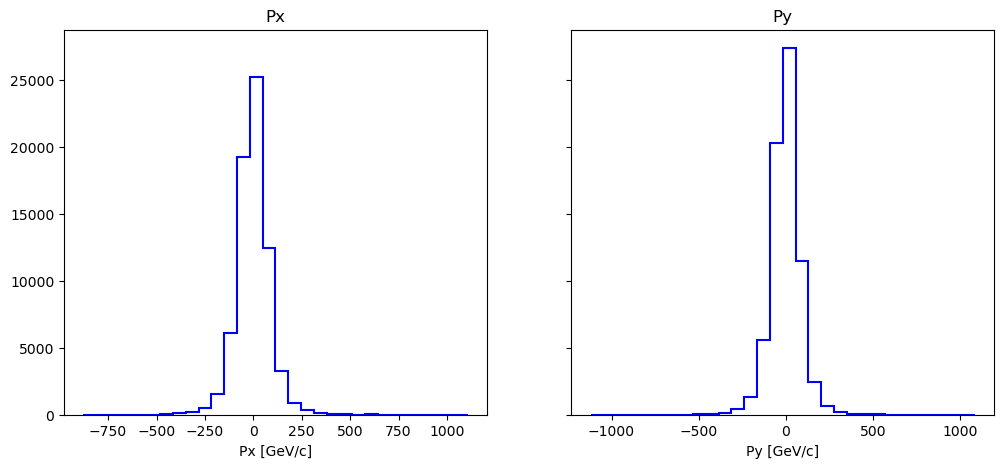

In [22]:
print("--------- MET  -----------")
draw_4momentum_from_data(train_dataset, 2, [0], False, True)

We can see that the momentums has gaussean shape arround 0, and the energies has only positive values and ne number of events decay with the energy 

#### Part 3b: Standardization

Hopefully you saw that the distributions of the various quantities we pass to the model can be quite different from each other! Neural networks can sometimes [train more easily](https://www.sciencedirect.com/science/article/pii/0305048396000102?via%3Dihub) (and thus reach better performance) when all of the features have roughly the same range of values. So, we should try _standardizing_ our input features, so that they all lie on a similar range. The most straightforward way to do this is by taking each feature, subtracting its mean, and dividing by its standard deviation:

$$ x_{i,j} \leftarrow \frac{x_{i,j} - \langle x_i \rangle}{\sigma_i} $$

where $i$ indexes over the different features (so $\langle x_i \rangle$ is the mean of the $i$th feature) and $j$ indexes over the samples in our dataset. This transformation will map any normal (Gaussian) distribution to the _standard normal distribution_ (Gaussian with $\mu=0$ and $\sigma=1$). On other distributions, it will preserve the shape, but shift it to be centered around zero and squeeze the values into a (usually) smaller range. Is this desirable for us? Try it and see!

The Scikit-Learn library provides a variety of methods for data standardization in their [preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html) module. The method I described above is implemented in the [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) class. You can use these if you wish, but be aware that you'll need to convert the PyTorch tensors from the datasets to Numpy arrays (you can use [`torch.Tensor.numpy()`](https://docs.pytorch.org/docs/stable/generated/torch.Tensor.numpy.html) for this), pass them through the scalers, then convert them back to tensors (using [`torch.as_tensor()`](https://docs.pytorch.org/docs/stable/generated/torch.as_tensor.html#torch.as_tensor) or similar).

Regardless of how you accomplish it, try to standardize the input features and train a model with them. If you expanded the parameter list in your training function to include the dataloaders, you'll be able to just create new dataloaders with your transformed inputs and pass them in!

- Lets standardize the input variables. In this case we will loop ovet the first 3 tensors of our dataset

In [23]:
train_data_std = [0,0,0,0,0]
valid_data_std = [0,0,0,0,0]

for i in range(3):
    train_tensor = train_dataset.tensors[i].numpy()
    valid_tensor = valid_dataset.tensors[i].numpy()
    # np.empty((7000, 8, 5))
    n_particles = len(train_tensor[0])
    n_variables = len(train_tensor[0][0])
    train_data_std[i] = np.empty((len(train_tensor), n_particles, n_variables)) 
    valid_data_std[i] = np.empty((len(valid_tensor), n_particles, n_variables)) 
    for particle in range(n_particles):
        for variable in range(n_variables):
            mean = 0
            std = 0
            train_data = train_tensor[:, particle, variable]
            valid_data = valid_tensor[:, particle, variable]
            mean = train_data.mean() 
            std = train_data.std()
            if std != 0:
                train_data_std[i][:,particle,variable] = (train_data  - mean)/std
                valid_data_std[i][:,particle,variable] = (valid_data  - mean)/std
            else:
                train_data_std[i][:,particle,variable] = train_data
                valid_data_std[i][:,particle,variable] = valid_data
            print(f"Tensor {i}, Particle {particle}, Variable {variable} | Mean: {train_data_std[i][:,particle,variable].mean():.4f}, Std: {train_data_std[i][:,particle,variable].std():.4f}")

                
train_data_std[3] = train_dataset.tensors[3].numpy()
valid_data_std[3] = valid_dataset.tensors[3].numpy()
train_data_std[4] = train_dataset.tensors[4].numpy()
valid_data_std[4] = valid_dataset.tensors[4].numpy()
from torch.utils.data import TensorDataset
# print(valid_data_std)
train_dataset_std= TensorDataset(torch.from_numpy(train_data_std[0].astype(np.float32)), torch.from_numpy(train_data_std[1].astype(np.float32)), torch.from_numpy(train_data_std[2].astype(np.float32)), torch.from_numpy(train_data_std[3].astype(np.float32)), torch.from_numpy(train_data_std[4].astype(np.float32)))
valid_dataset_std= TensorDataset(torch.from_numpy(valid_data_std[0].astype(np.float32)), torch.from_numpy(valid_data_std[1].astype(np.float32)), torch.from_numpy(valid_data_std[2].astype(np.float32)), torch.from_numpy(valid_data_std[3].astype(np.float32)), torch.from_numpy(valid_data_std[4].astype(np.float32)))
# print(valid_dataset_std.tensors)

Tensor 0, Particle 0, Variable 0 | Mean: 0.0000, Std: 1.0000
Tensor 0, Particle 0, Variable 1 | Mean: 0.0000, Std: 1.0000
Tensor 0, Particle 0, Variable 2 | Mean: 0.0000, Std: 1.0000
Tensor 0, Particle 0, Variable 3 | Mean: 0.0000, Std: 1.0000
Tensor 0, Particle 0, Variable 4 | Mean: -0.0000, Std: 1.0000
Tensor 0, Particle 1, Variable 0 | Mean: 0.0000, Std: 1.0000
Tensor 0, Particle 1, Variable 1 | Mean: -0.0000, Std: 1.0000
Tensor 0, Particle 1, Variable 2 | Mean: -0.0000, Std: 1.0000
Tensor 0, Particle 1, Variable 3 | Mean: 0.0000, Std: 1.0000
Tensor 0, Particle 1, Variable 4 | Mean: 0.0000, Std: 1.0000
Tensor 0, Particle 2, Variable 0 | Mean: 0.0000, Std: 1.0000
Tensor 0, Particle 2, Variable 1 | Mean: -0.0000, Std: 1.0000
Tensor 0, Particle 2, Variable 2 | Mean: -0.0000, Std: 1.0000
Tensor 0, Particle 2, Variable 3 | Mean: 0.0000, Std: 1.0000
Tensor 0, Particle 2, Variable 4 | Mean: 0.0000, Std: 1.0000
Tensor 0, Particle 3, Variable 0 | Mean: -0.0000, Std: 1.0000
Tensor 0, Particle

Lets plot the variable again to see if it works.

--------- 2 leading Jets -----------


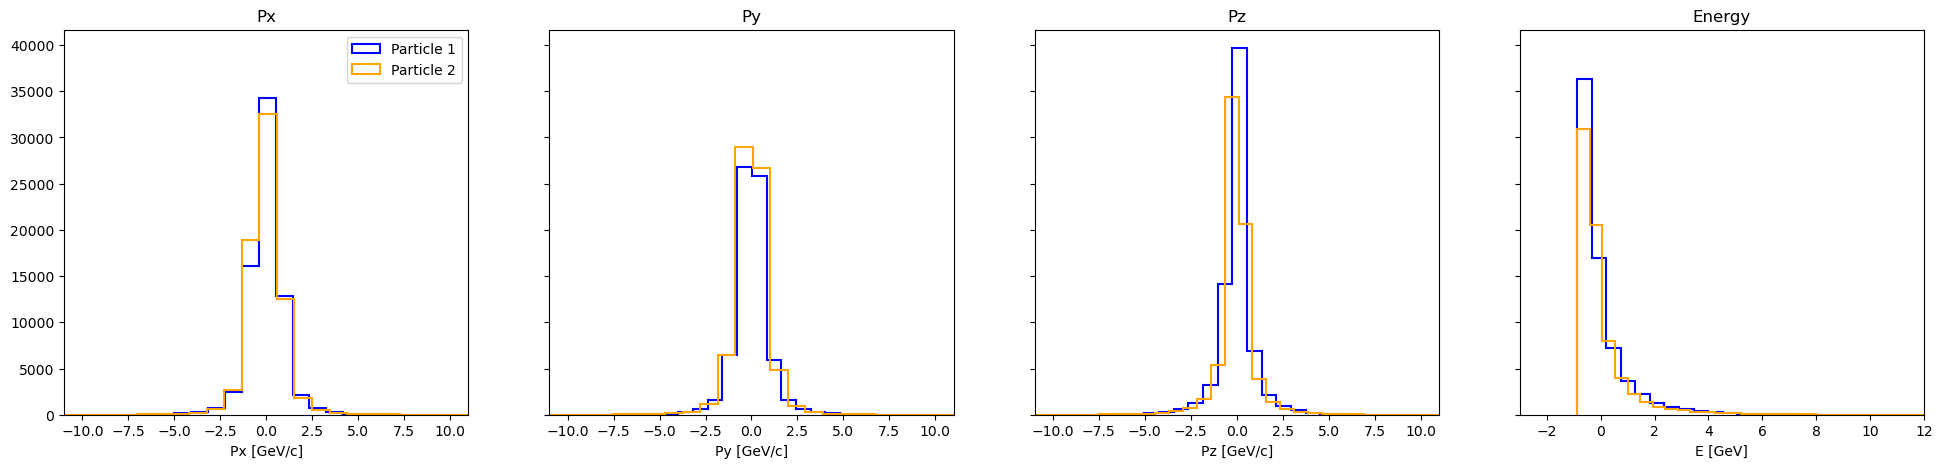

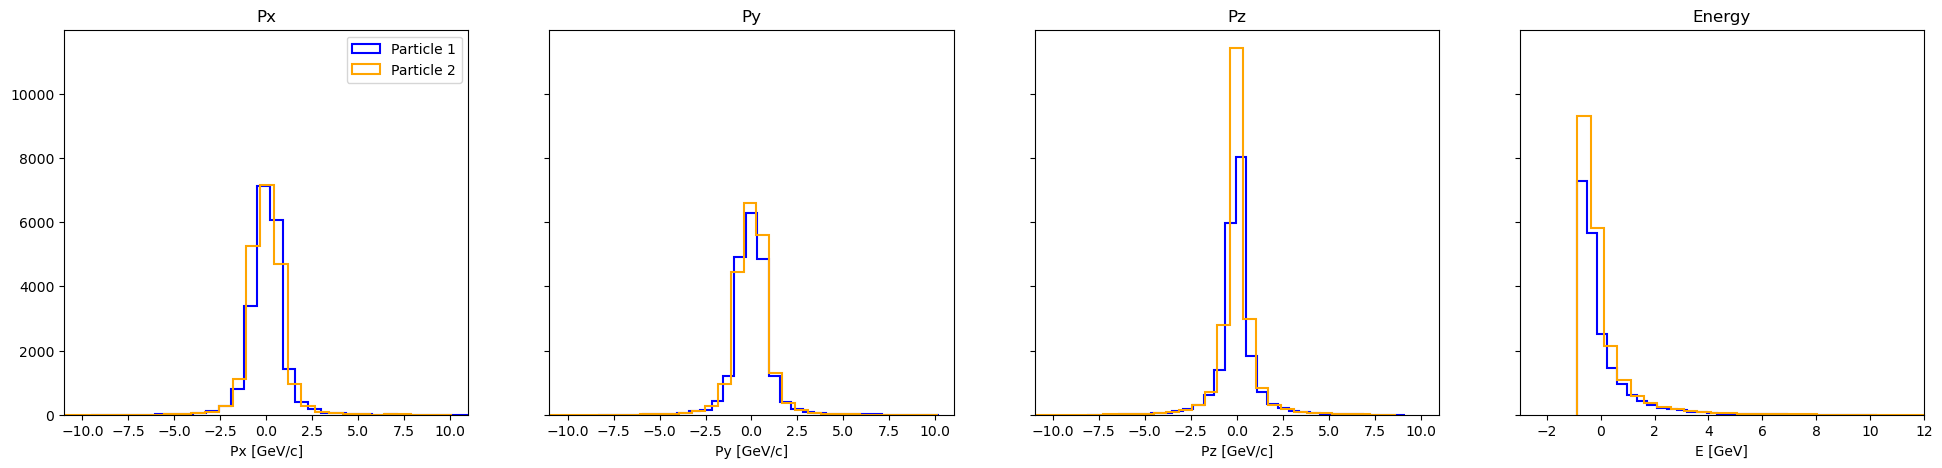

In [24]:
print("--------- 2 leading Jets -----------")
draw_4momentum_from_data(train_dataset_std, 0, [0,1], True)
draw_4momentum_from_data(valid_dataset_std, 0, [0,1], True)

--------- 2 Leptons  -----------


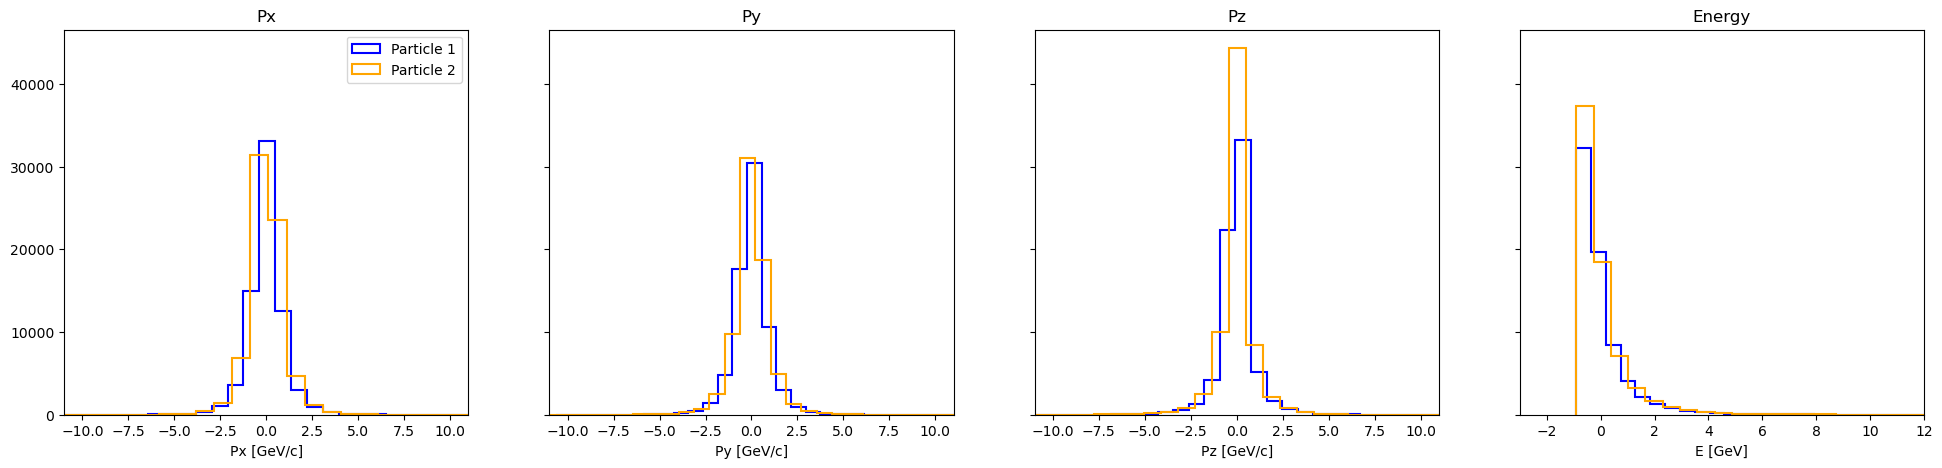

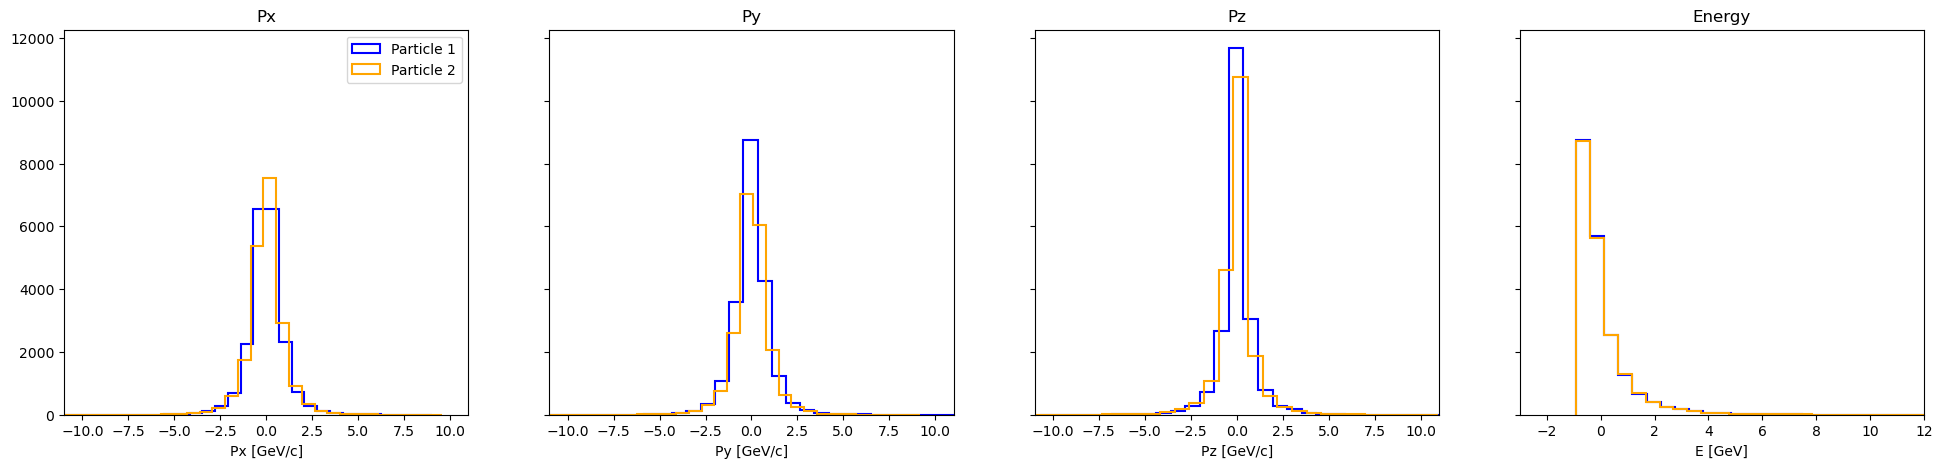

In [25]:
print("--------- 2 Leptons  -----------")
draw_4momentum_from_data(train_dataset_std, 1, [0,1], True)
draw_4momentum_from_data(valid_dataset_std, 1, [0,1], True)

--------- 2 Tops quarks  -----------


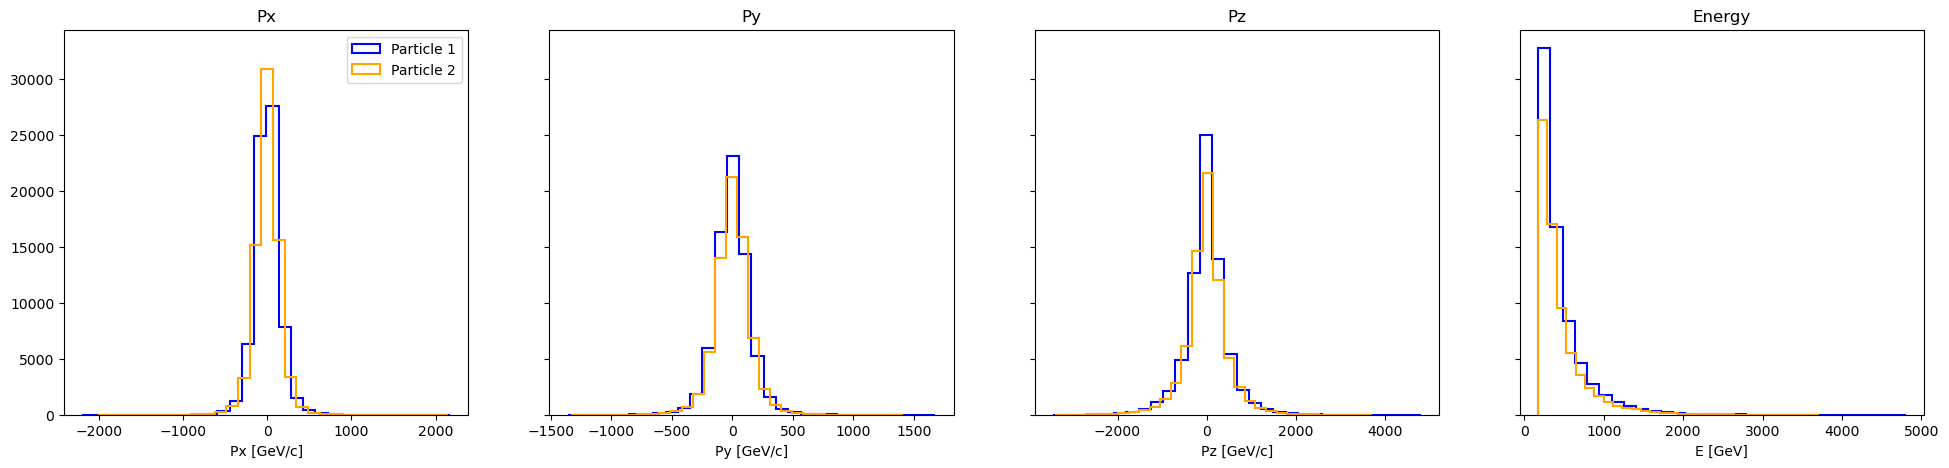

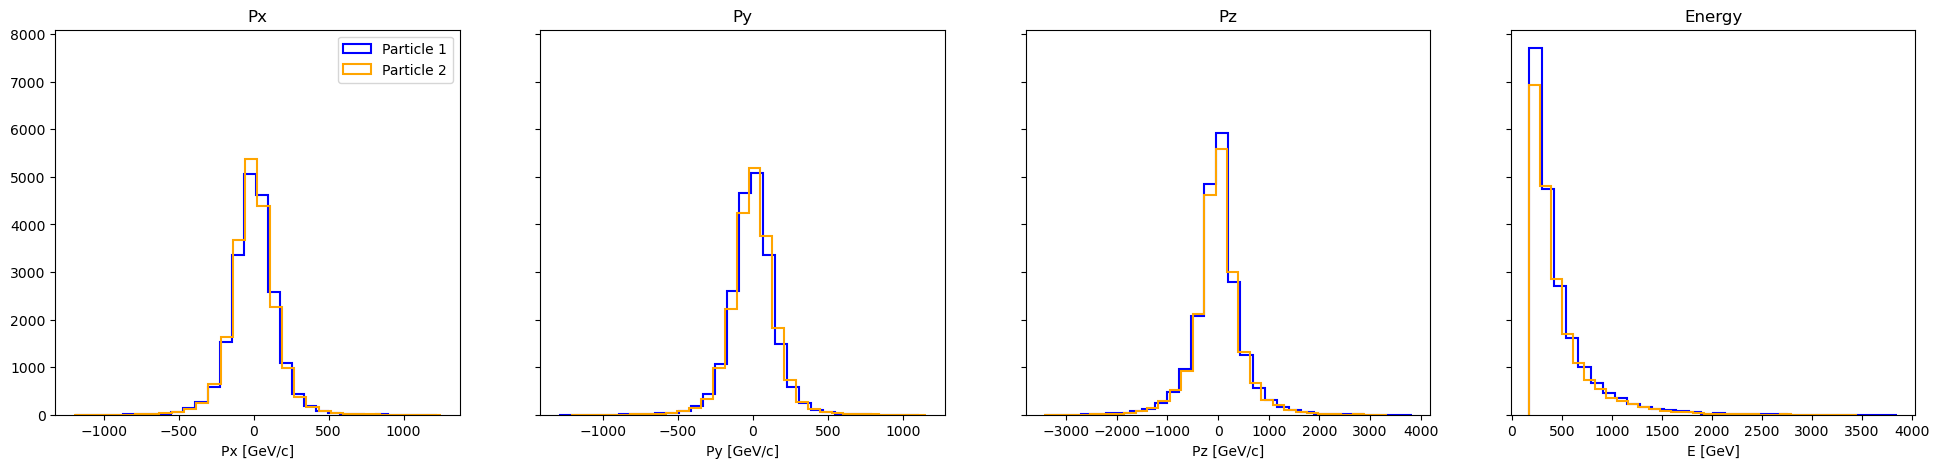

In [26]:
print("--------- 2 Tops quarks  -----------")
draw_4momentum_from_data(train_dataset_std, 4, [0,1])
draw_4momentum_from_data(valid_dataset_std, 4, [0,1])

--------- MET  -----------


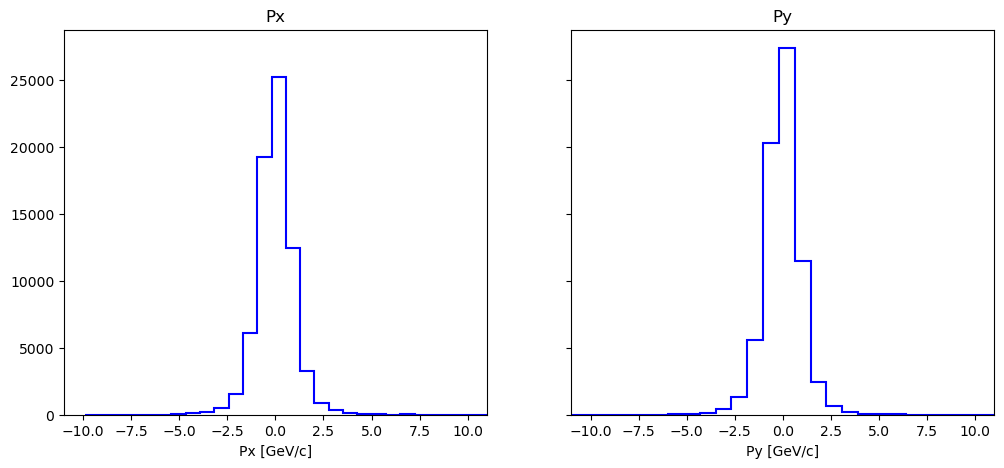

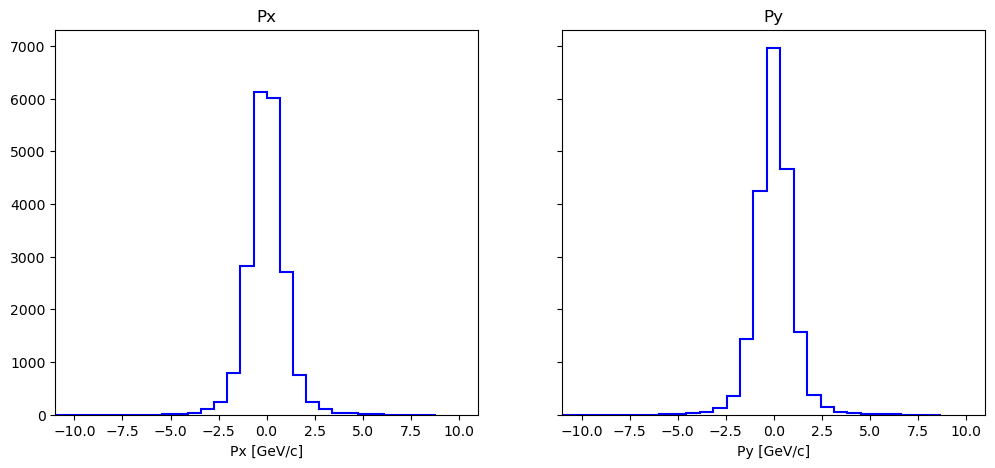

In [27]:
print("--------- MET  -----------")
draw_4momentum_from_data(train_dataset_std, 2, [0], True, True)
draw_4momentum_from_data(valid_dataset_std, 2, [0], True, True)

According to the plots, it seems that the standardization process works fine. We see that the distributions are squeezed. Also, the targets are unaffected.

Now we can update the dataloaders

In [28]:
if torch.cuda.is_available():
    train_dataloader_std = torch.utils.data.DataLoader(train_dataset_std, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)
    valid_dataloader_std = torch.utils.data.DataLoader(valid_dataset_std, batch_size=valid_batch_size, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)
else:
    train_dataloader_std = torch.utils.data.DataLoader(train_dataset_std, batch_size=batch_size, shuffle=True, drop_last=True)
    valid_dataloader_std = torch.utils.data.DataLoader(valid_dataset_std, batch_size=valid_batch_size, shuffle=True, drop_last=True)

valid_dataloader_iterator_std = cycle(valid_dataloader_std)

In [29]:
%%time

model_nl4_std = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_nl4_std = model_nl4_std.to(device)

optimizer = torch.optim.Adam(model_nl4_std.parameters(), lr=learning_rate, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["nl-4_std"], loss_validation_map["nl-4_std"], error_train_map["nl-4_std"], error_validation_map["nl-4_std"] = train_my_model(model_nl4_std, optimizer, loss_function, train_dataloader_std, valid_dataloader_iterator_std, "nl-4_std", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 9.32 s, sys: 3.72 s, total: 13 s
Wall time: 52.6 s


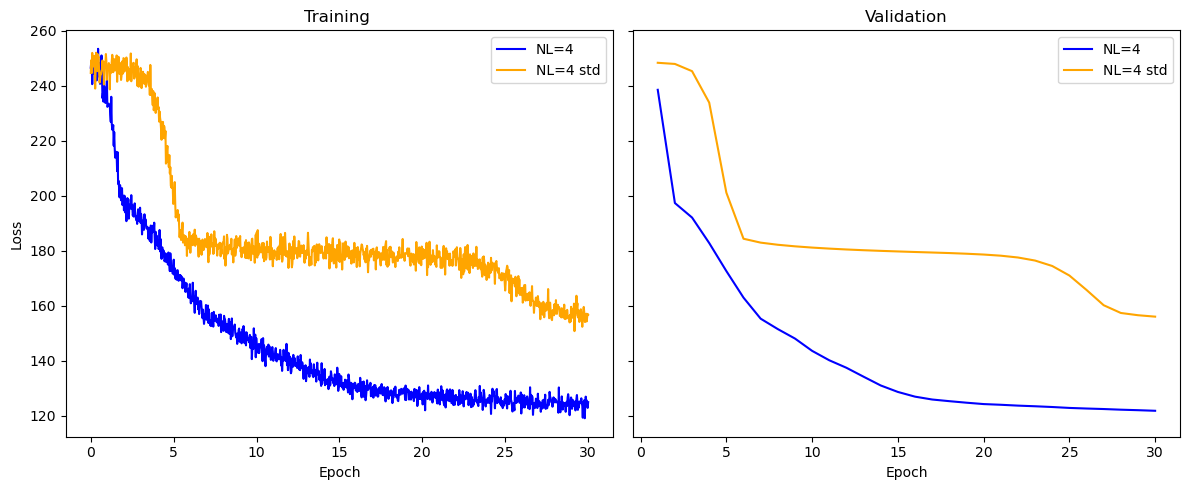

In [30]:
draw_losses(["nl-4", "nl-4_std"], ["NL=4", "NL=4 std"])

We can see that standardize the variable does not improve our results. This does not means that this does not work, maybe we need to play with the parameters (layer, learning rates, etc) to get the best possible result. Lets try to incresse the learning rate to see thise

In [31]:
%%time

model_nl4_std = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_nl4_std = model_nl4_std.to(device)

optimizer = torch.optim.Adam(model_nl4_std.parameters(), lr=50e-4, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["nl-4_std_lr"], loss_validation_map["nl-4_std_lr"], _, _ = train_my_model(model_nl4_std, optimizer, loss_function, train_dataloader_std, valid_dataloader_iterator_std, "nl-4_std", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 8.52 s, sys: 3.58 s, total: 12.1 s
Wall time: 49.4 s


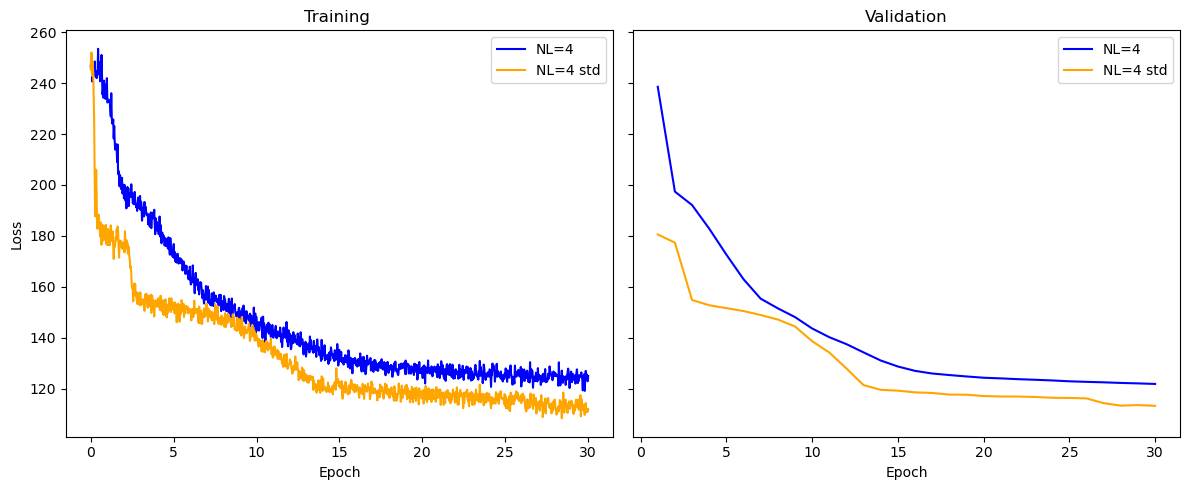

In [32]:
draw_losses(["nl-4", "nl-4_std_lr"], ["NL=4", "NL=4 std"])

Here we can see that it actually improves the learning. So, if we want to strandarize the variable we need to check our parameters.

#### Part 3c: Standardizing Outputs

Just like input features, _output features_ can also be standardized. This is simple in training, but complicates evaluation a bit - in order to interpret the predictions your model makes, you'll need to _invert the transformation_. Here's where the Scikit-Learn classes can come in handy - they implement an `inverse_transform()` method that can do this inversion easily. Try training with standardized outputs, both with and without standardizing inputs. Which combination performs the best? Why might this be the case?

Hint: if you're having trouble getting your tensor(s) of model predictions into Numpy arrays to invert the scaling, you may need to use something like `output_tensor.detach().to("cpu").numpy()`. This detaches your tensor from PyTorch's computational graph, moves the data to CPU memory if it's on the GPU, and _only then_ converts it to Numpy. A slightly less safe alternative is `output_tensor.numpy(force=True)`, which does these things and a couple of others to ensure Numpy can work with the data in the tensor.

Note: if you already standardized your output features along with your inputs before, that's totally fine, no need to change that! Just train with only inputs (and only outputs) standardized now, and comment on the results.

In [33]:
mean = 0
std = 0

i = 4
train_tensor = train_dataset.tensors[i].numpy()
valid_tensor = valid_dataset.tensors[i].numpy()
# np.empty((7000, 8, 5))
n_particles = len(train_tensor[0])
n_variables = len(train_tensor[0][0])
train_data_std[i] = np.empty((len(train_tensor), n_particles, n_variables)) 
valid_data_std[i] = np.empty((len(valid_tensor), n_particles, n_variables)) 
std_tops =[[0,0,0,0],[0,0,0,0]]
mean_tops =[[0,0,0,0],[0,0,0,0]]
for particle in range(n_particles):
    for variable in range(n_variables):
        train_data = train_tensor[:, particle, variable]
        valid_data = valid_tensor[:, particle, variable]
        mean = train_data.mean() 
        std = train_data.std()
        if std != 0:
            train_data_std[i][:,particle,variable] = (train_data  - mean)/std
            valid_data_std[i][:,particle,variable] = (valid_data  - mean)/std
        else:
            train_data_std[i][:,particle,variable] = train_data
            valid_data_std[i][:,particle,variable] = valid_data
        std_tops[particle][variable] = std
        mean_tops[particle][variable] = mean
                


train_dataset_std= TensorDataset(torch.from_numpy(train_data_std[0].astype(np.float32)), torch.from_numpy(train_data_std[1].astype(np.float32)), torch.from_numpy(train_data_std[2].astype(np.float32)), torch.from_numpy(train_data_std[3].astype(np.float32)), torch.from_numpy(train_data_std[4].astype(np.float32)))
valid_dataset_std= TensorDataset(torch.from_numpy(valid_data_std[0].astype(np.float32)), torch.from_numpy(valid_data_std[1].astype(np.float32)), torch.from_numpy(valid_data_std[2].astype(np.float32)), torch.from_numpy(valid_data_std[3].astype(np.float32)), torch.from_numpy(valid_data_std[4].astype(np.float32)))

--------- 2 Tops quarks  -----------


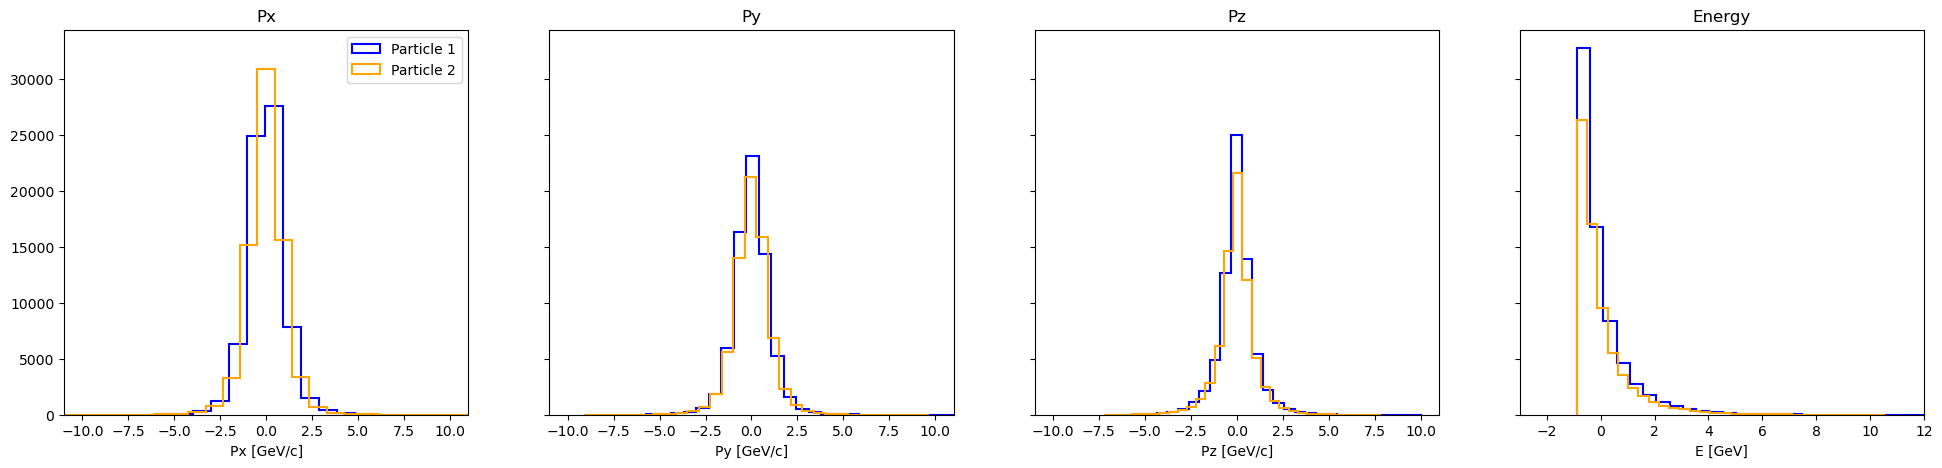

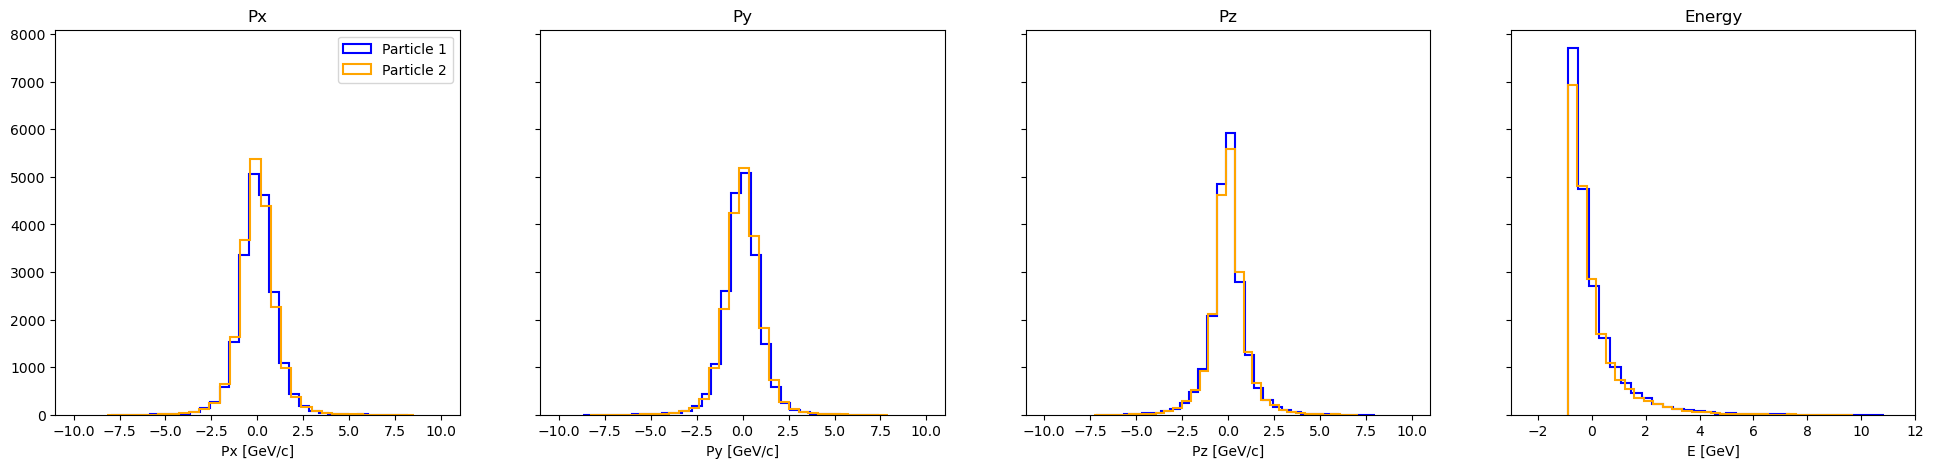

In [34]:
print("--------- 2 Tops quarks  -----------")
draw_4momentum_from_data(train_dataset_std, 4, [0,1], True)
draw_4momentum_from_data(valid_dataset_std, 4, [0,1], True)

tops quarks four momentum seems ok. We have to update out dataloarders again

In [35]:
if torch.cuda.is_available():
    train_dataloader_std = torch.utils.data.DataLoader(train_dataset_std, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)
    valid_dataloader_std = torch.utils.data.DataLoader(valid_dataset_std, batch_size=valid_batch_size, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)
else:
    train_dataloader_std = torch.utils.data.DataLoader(train_dataset_std, batch_size=batch_size, shuffle=True, drop_last=True)
    valid_dataloader_std = torch.utils.data.DataLoader(valid_dataset_std, batch_size=valid_batch_size, shuffle=True, drop_last=True)

valid_dataloader_iterator_std = cycle(valid_dataloader_std)

In [36]:
%%time

model_nl4_std_in_out = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_nl4_std_in_out = model_nl4_std_in_out.to(device)


optimizer = torch.optim.Adam(model_nl4_std_in_out.parameters(), lr=learning_rate, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["nl-4_std-in-out"], loss_validation_map["nl-4_std-in-out"],error_train_map["nl-4_std-in-out"], error_validation_map["nl-4_std-in-out"] = train_my_model(model_nl4_std_in_out, optimizer, loss_function, train_dataloader_std, valid_dataloader_iterator_std, "nl-4_std_in_out", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 8.14 s, sys: 3.69 s, total: 11.8 s
Wall time: 47.2 s


Now want to check the effect of standardize only se outputs, so lets move again our inputs variable to their original value

In [37]:
train_data_std[0] = train_dataset.tensors[0].numpy()
valid_data_std[0] = valid_dataset.tensors[0].numpy()
train_data_std[1] = train_dataset.tensors[1].numpy()
valid_data_std[1] = valid_dataset.tensors[1].numpy()                
train_data_std[2] = train_dataset.tensors[2].numpy()
valid_data_std[2] = valid_dataset.tensors[2].numpy()
train_data_std[3] = train_dataset.tensors[3].numpy()
valid_data_std[3] = valid_dataset.tensors[3].numpy()
from torch.utils.data import TensorDataset

train_dataset_std= TensorDataset(torch.from_numpy(train_data_std[0].astype(np.float32)), torch.from_numpy(train_data_std[1].astype(np.float32)), torch.from_numpy(train_data_std[2].astype(np.float32)), torch.from_numpy(train_data_std[3].astype(np.float32)), torch.from_numpy(train_data_std[4].astype(np.float32)))
valid_dataset_std= TensorDataset(torch.from_numpy(valid_data_std[0].astype(np.float32)), torch.from_numpy(valid_data_std[1].astype(np.float32)), torch.from_numpy(valid_data_std[2].astype(np.float32)), torch.from_numpy(valid_data_std[3].astype(np.float32)), torch.from_numpy(valid_data_std[4].astype(np.float32)))

if torch.cuda.is_available():
    train_dataloader_std = torch.utils.data.DataLoader(train_dataset_std, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)
    valid_dataloader_std = torch.utils.data.DataLoader(valid_dataset_std, batch_size=valid_batch_size, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)
else:
    train_dataloader_std = torch.utils.data.DataLoader(train_dataset_std, batch_size=batch_size, shuffle=True, drop_last=True)
    valid_dataloader_std = torch.utils.data.DataLoader(valid_dataset_std, batch_size=valid_batch_size, shuffle=True, drop_last=True)

valid_dataloader_iterator_std = cycle(valid_dataloader_std)

--------- 2 Tops quarks  -----------


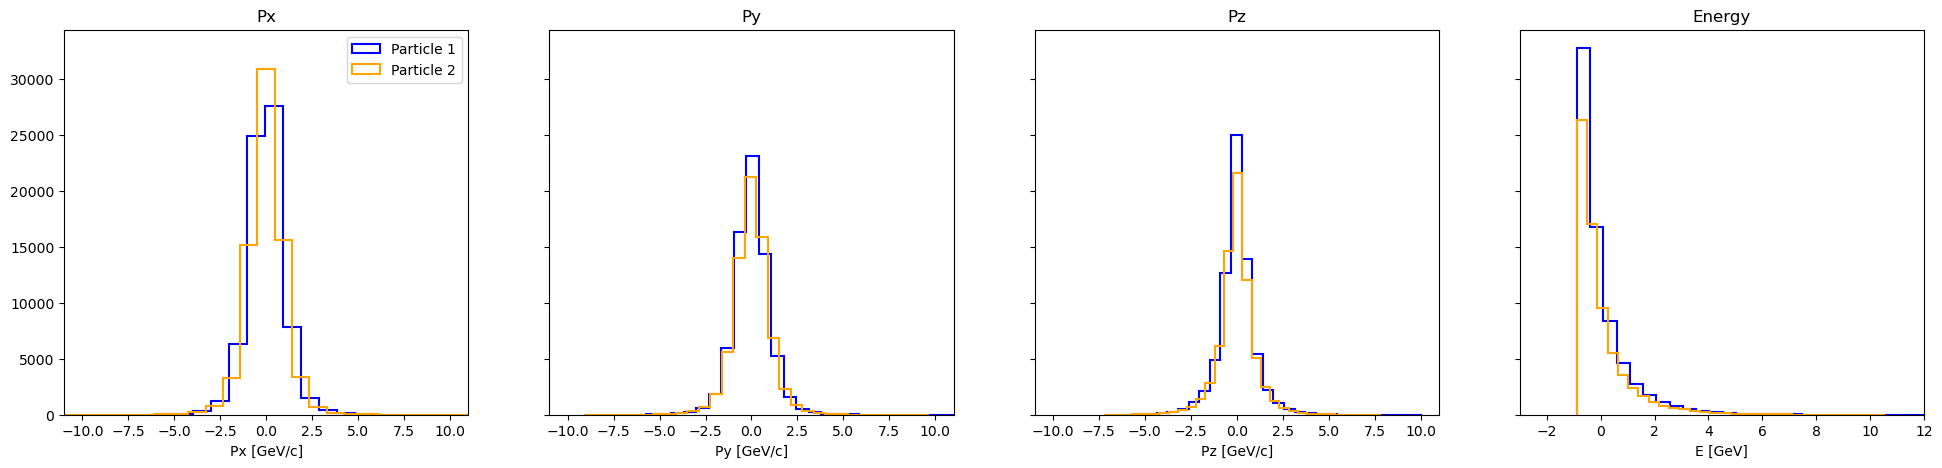

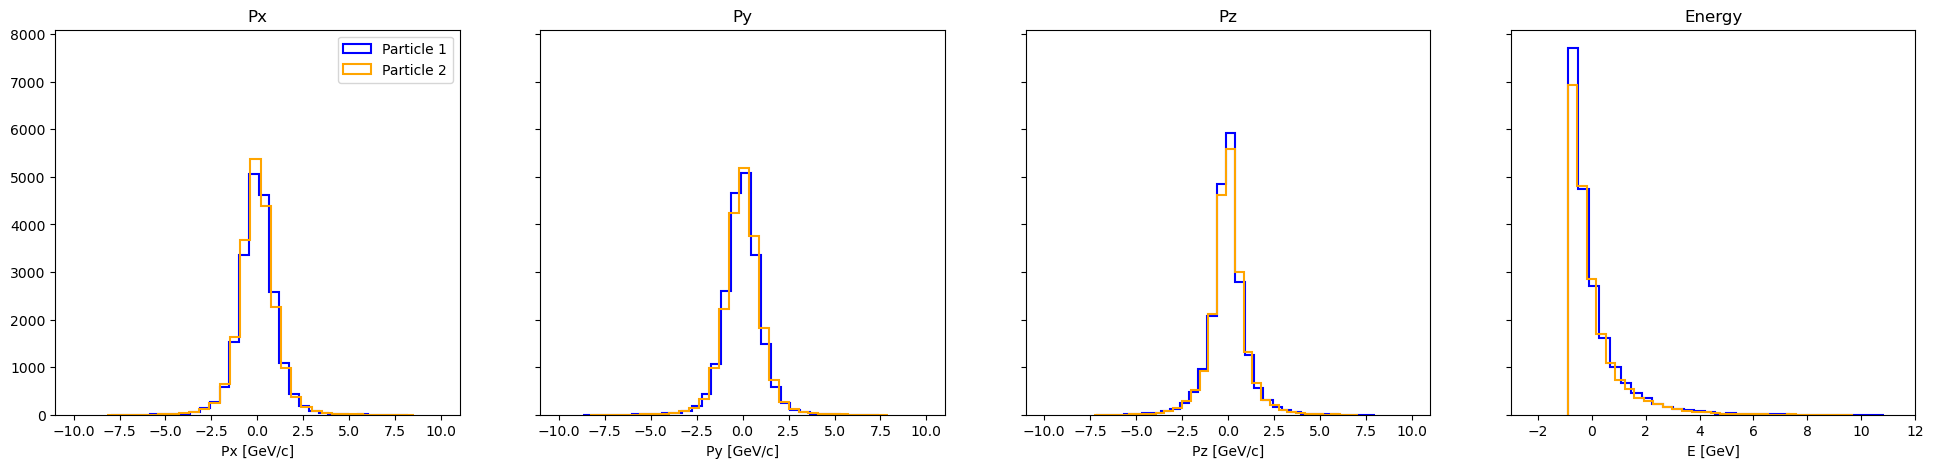

--------- 2 Leptons  -----------


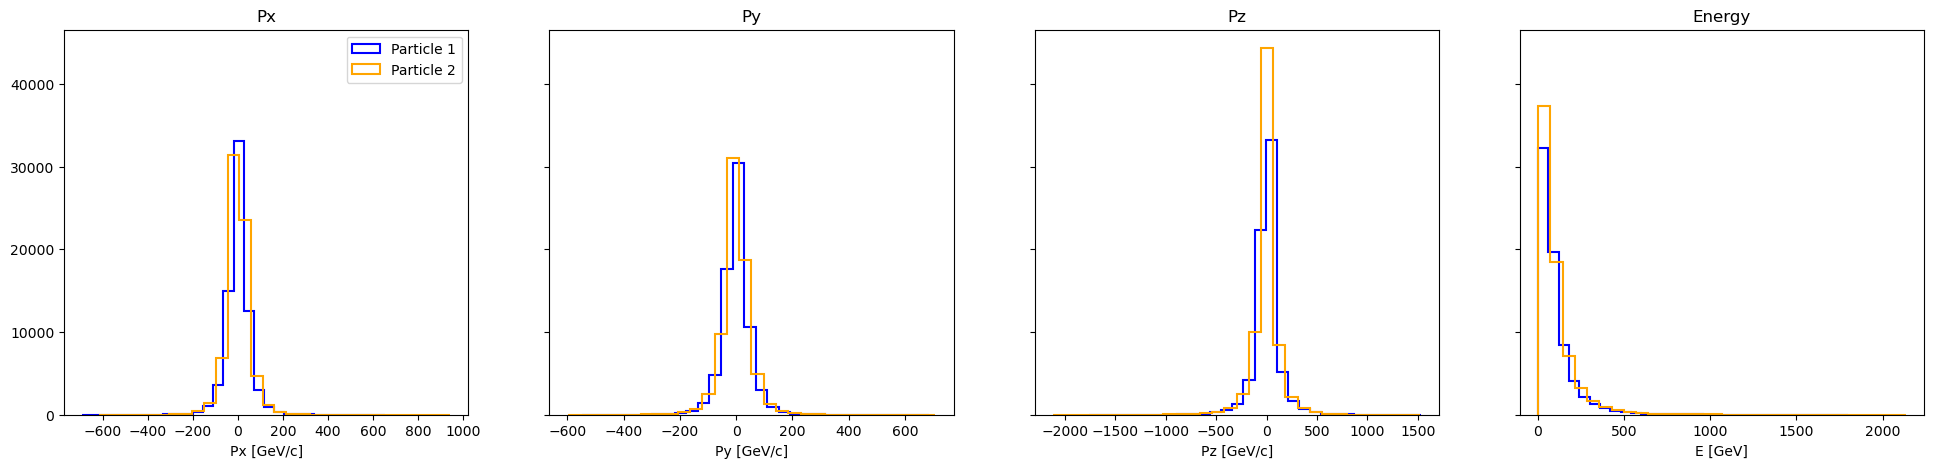

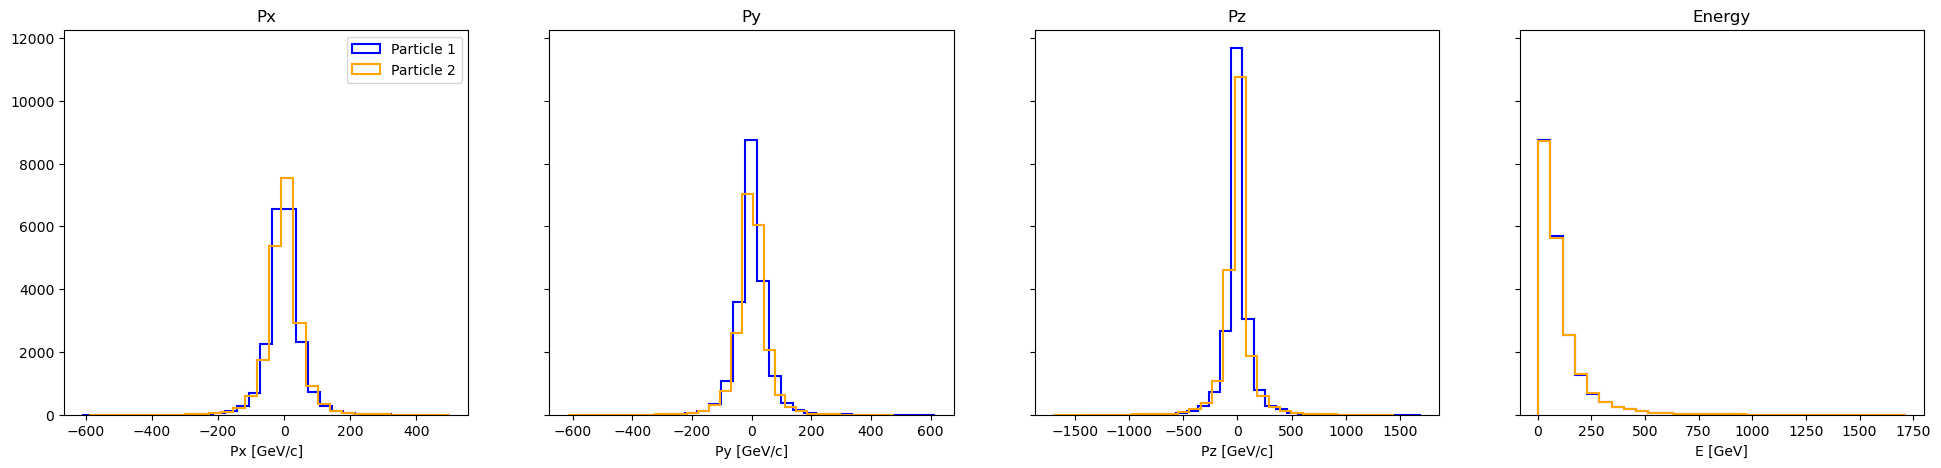

In [38]:
print("--------- 2 Tops quarks  -----------")
draw_4momentum_from_data(train_dataset_std, 4, [0,1], True)
draw_4momentum_from_data(valid_dataset_std, 4, [0,1], True)

print("--------- 2 Leptons  -----------")
draw_4momentum_from_data(train_dataset_std, 1, [0,1])
draw_4momentum_from_data(valid_dataset_std, 1, [0,1])

In [39]:
%%time

model_nl4_std_out = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_nl4_std_out = model_nl4_std_out.to(device)


optimizer = torch.optim.Adam(model_nl4_std_out.parameters(), lr=learning_rate, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["nl-4_std-out"], loss_validation_map["nl-4_std-out"],error_train_map["nl-4_std-out"], error_validation_map["nl-4_std-out"] = train_my_model(model_nl4_std_out, optimizer, loss_function, train_dataloader_std, valid_dataloader_iterator_std, "nl-4_std_out", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 8.74 s, sys: 3.7 s, total: 12.4 s
Wall time: 45.7 s


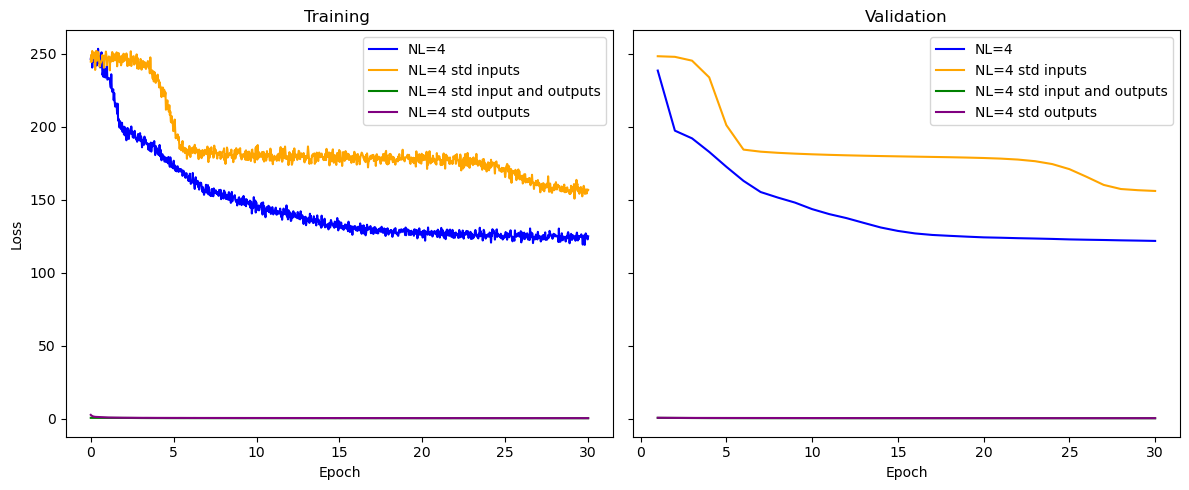

In [40]:
draw_losses(["nl-4","nl-4_std", "nl-4_std-in-out","nl-4_std-out"], ["NL=4", "NL=4 std inputs","NL=4 std input and outputs", "NL=4 std outputs"])

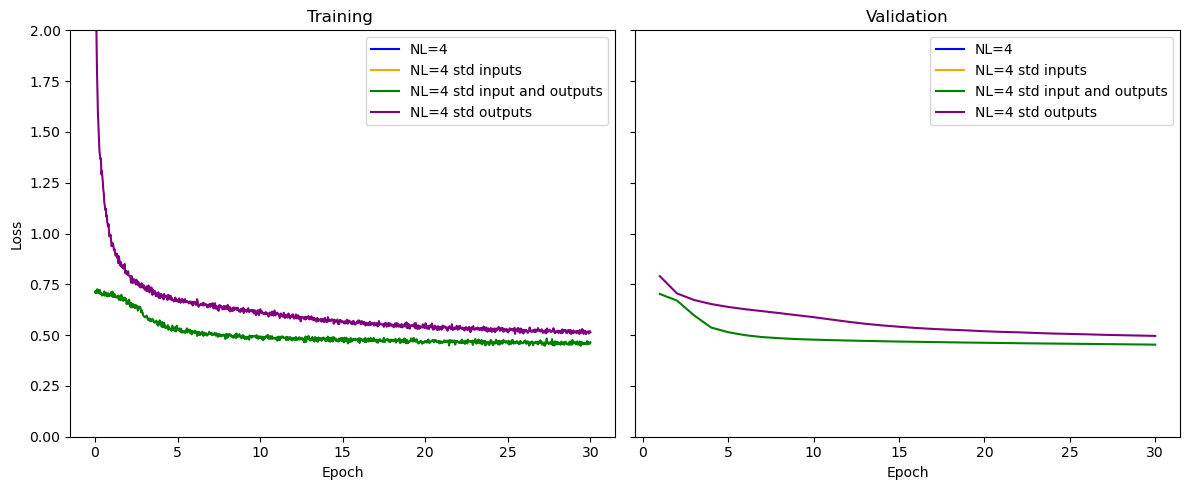

In [41]:
draw_losses(["nl-4","nl-4_std", "nl-4_std-in-out","nl-4_std-out"], ["NL=4", "NL=4 std inputs","NL=4 std input and outputs", "NL=4 std outputs"],True, [0,2])

The cases with standardize output the loss a much smaller. This make sense because the loss is define in base as $|y_real - y_pred|$ so they are in a diffent scale. Lest try to put it in the same scale by multiplying by the std.

In [42]:
std_mean = np.array(std_tops).mean()
loss_train_map["nl-4_std-in-out"] = np.array(loss_train_map["nl-4_std-in-out"])*std_mean
loss_validation_map["nl-4_std-in-out"] = np.array(loss_validation_map["nl-4_std-in-out"])*std_mean
loss_train_map["nl-4_std-out"] = np.array(loss_train_map["nl-4_std-out"])*std_mean
loss_validation_map["nl-4_std-out"] = np.array(loss_validation_map["nl-4_std-out"])*std_mean


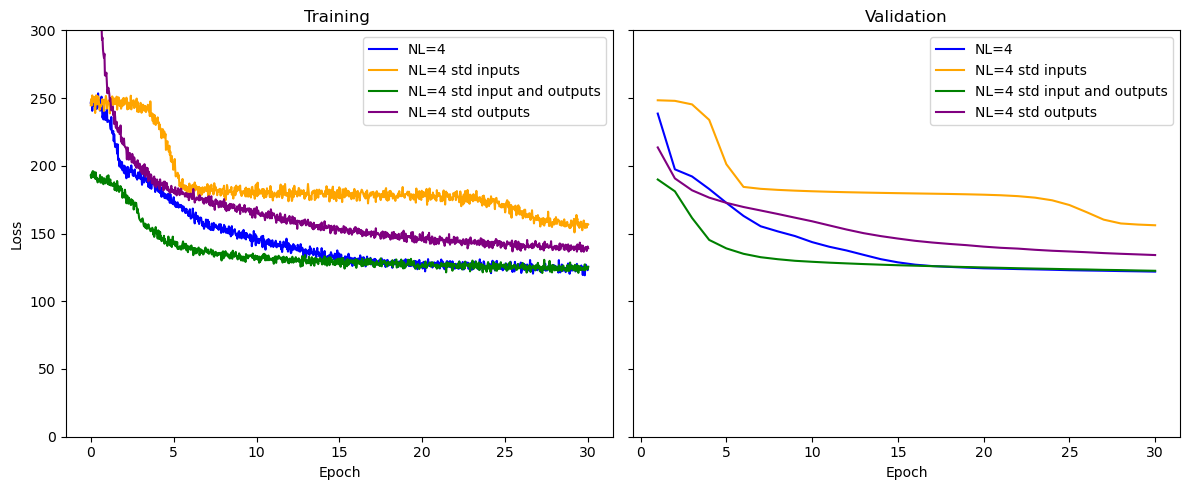

In [59]:
draw_losses(["nl-4","nl-4_std", "nl-4_std-in-out","nl-4_std-out"], ["NL=4", "NL=4 std inputs","NL=4 std input and outputs", "NL=4 std outputs"] , True, [0,300])

Now it seems that all the model behave pretty similar. Again we need to be carefull because each case may need its own parameters 

### Problem 4: Other Training Settings

As a final problem, experiment with other _hyperparameters_ (settings for our training process). Run several trainings, varying at least two of these things:
- Change the _batch size_ to be larger or smaller (create new dataloaders using the same datasets). How big do batches need to be?
- Change the learning rate (when you create the optimizer). Try several values and try to find the best one! Does this optimal value depend on the batch size? Why might this be?
- Use a different loss function than you have so far. Try [MSE](https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html), [L1 Loss (MAE)](https://docs.pytorch.org/docs/stable/generated/torch.nn.L1Loss), and [Huber loss](https://docs.pytorch.org/docs/2.8/generated/torch.nn.HuberLoss.html), all of which are common in regression problems like this.

Compare the results of your different trainings. Were any of the optimal settings surprising to you? Why (or why not)?

Lets define models varying Batch size, learning rate, and loss function

In [44]:
%%time
model_lr05 = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_lr05 = model_lr05.to(device)
# learning_rate = 1.0e-4
# print("Trainable parameters:", sum(p.numel() for p in model_nl4.parameters() if p.requires_grad))
optimizer = torch.optim.Adam(model_lr05.parameters(), lr=.5e-4, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["lr05"], loss_validation_map["lr05"],_,_ = train_my_model(model_lr05, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "lr05", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 8.55 s, sys: 3.66 s, total: 12.2 s
Wall time: 48.7 s


In [45]:
%%time
model_lr2 = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_lr2 = model_lr2.to(device)
# learning_rate = 1.0e-4
# print("Trainable parameters:", sum(p.numel() for p in model_nl4.parameters() if p.requires_grad))
optimizer = torch.optim.Adam(model_lr2.parameters(), lr=2e-4, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["lr2"], loss_validation_map["lr2"],_,_ = train_my_model(model_lr2, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "lr2", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 8.73 s, sys: 3.72 s, total: 12.5 s
Wall time: 49.4 s


In [46]:
%%time
model_lr4 = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_lr4 = model_lr4.to(device)

optimizer = torch.optim.Adam(model_lr4.parameters(), lr=4e-4, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["lr4"], loss_validation_map["lr4"],_,_ = train_my_model(model_lr4, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "lr4", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 8.51 s, sys: 3.81 s, total: 12.3 s
Wall time: 47 s


In [47]:
%%time
model_MSE = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_MSE = model_MSE.to(device)

optimizer = torch.optim.Adam(model_MSE.parameters(), lr=1e-4, weight_decay=0.0)
loss_function = torch.nn.MSELoss(reduction="mean")
_, loss_train_map["MSE"], loss_validation_map["MSE"],error_train_map["MSE"], error_validation_map["MSE"] = train_my_model(model_MSE, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "MSE", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 8.06 s, sys: 3.77 s, total: 11.8 s
Wall time: 46.8 s


In [48]:
%%time
model_Huber = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_HuberE = model_Huber.to(device)
# learning_rate = 1.0e-4
# print("Trainable parameters:", sum(p.numel() for p in model_nl4.parameters() if p.requires_grad))
optimizer = torch.optim.Adam(model_Huber.parameters(), lr=1e-4, weight_decay=0.0)
loss_function = torch.nn.HuberLoss(reduction="mean")
_, loss_train_map["Huber"], loss_validation_map["Huber"],error_train_map["Huber"], error_validation_map["Huber"] = train_my_model(model_Huber, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "Huber", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 8.48 s, sys: 3.73 s, total: 12.2 s
Wall time: 47.9 s


In [49]:
%%time
batch_size = 1024


if torch.cuda.is_available():
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)
else:
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

model_bz1024 = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_bz1024 = model_bz1024.to(device)
# learning_rate = 1.0e-4
# print("Trainable parameters:", sum(p.numel() for p in model_nl4.parameters() if p.requires_grad))
optimizer = torch.optim.Adam(model_bz1024.parameters(), lr=1e-4, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["bz1024"], loss_validation_map["bz1024"],_,_ = train_my_model(model_bz1024, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "bz1024", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 15.1 s, sys: 4.88 s, total: 20 s
Wall time: 46.5 s


In [50]:
%%time
batch_size = 4096


if torch.cuda.is_available():
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)
else:
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

model_bz4096 = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_bz4096 = model_bz4096.to(device)
# learning_rate = 1.0e-4
# print("Trainable parameters:", sum(p.numel() for p in model_nl4.parameters() if p.requires_grad))
optimizer = torch.optim.Adam(model_bz4096.parameters(), lr=1e-4, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["bz4096"], loss_validation_map["bz4096"],_,_ = train_my_model(model_bz4096, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "bz4096", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 4.66 s, sys: 3.01 s, total: 7.67 s
Wall time: 49.8 s


In [51]:
%%time
batch_size = 8192


if torch.cuda.is_available():
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)
else:
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

model_bz8192 = MLPModel(d_input=52, n_layers= 4, d_layers=192, d_output=8, dropout= 0.1)
model_bz8192 = model_bz8192.to(device)

optimizer = torch.optim.Adam(model_bz8192.parameters(), lr=1e-4, weight_decay=0.0)
loss_function = torch.nn.L1Loss(reduction="mean")
_, loss_train_map["bz8192"], loss_validation_map["bz8192"],_,_ = train_my_model(model_bz8192, optimizer, loss_function, train_dataloader, valid_dataloader_iterator, "bz8192", epochs=30)

Trainable parameters: 122888
Starting epoch 10.
Starting epoch 20.
Starting epoch 30.
Done with the training.
CPU times: user 2.95 s, sys: 2.95 s, total: 5.9 s
Wall time: 48.9 s


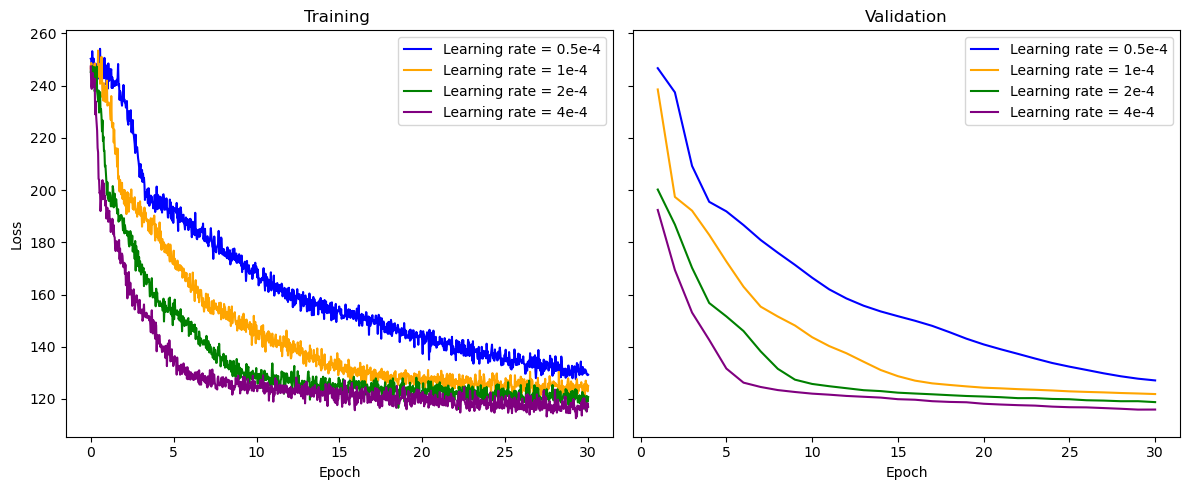

In [52]:
draw_losses(["lr05", "nl-4", "lr2", "lr4"], ["Learning rate = 0.5e-4", "Learning rate = 1e-4", "Learning rate = 2e-4", "Learning rate = 4e-4"])

We can see that in this case increase the learning rate makes our model converge faster to the minimun loss

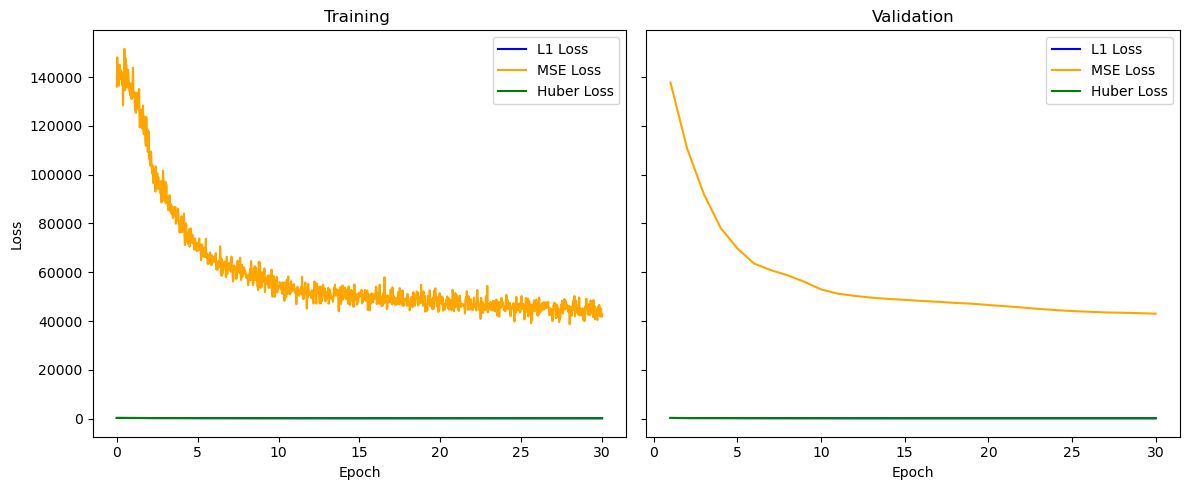

In [53]:
draw_losses(["nl-4", "MSE", "Huber"], ["L1 Loss", "MSE Loss", "Huber Loss"])

In this case, compare the losses is not useful, because the definitions are differente so they are by definition in different scales. Lets plot the error $\sum_i \frac{1}{N}|y_{real}^{(i)} - y_{pred}^{(i)}|$. Important to remark that this is the L1 loss, but it is use just for the plot, not for the train. 

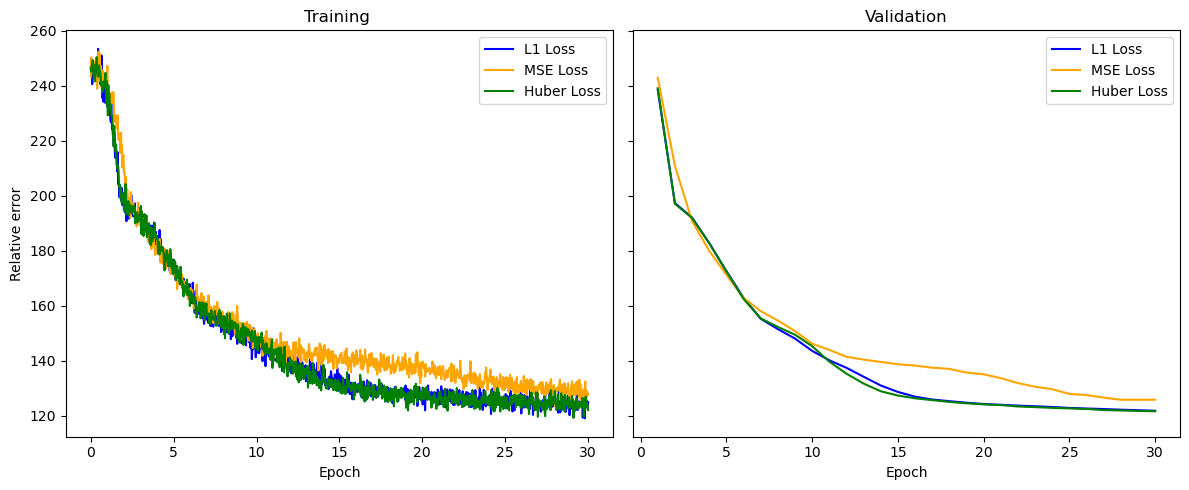

In [54]:
draw_losses(["nl-4", "MSE", "Huber"], ["L1 Loss", "MSE Loss", "Huber Loss"], False)

L1 and Huber seems to work slightly better than MSE, but they all seems to reach the same perfomance at the end

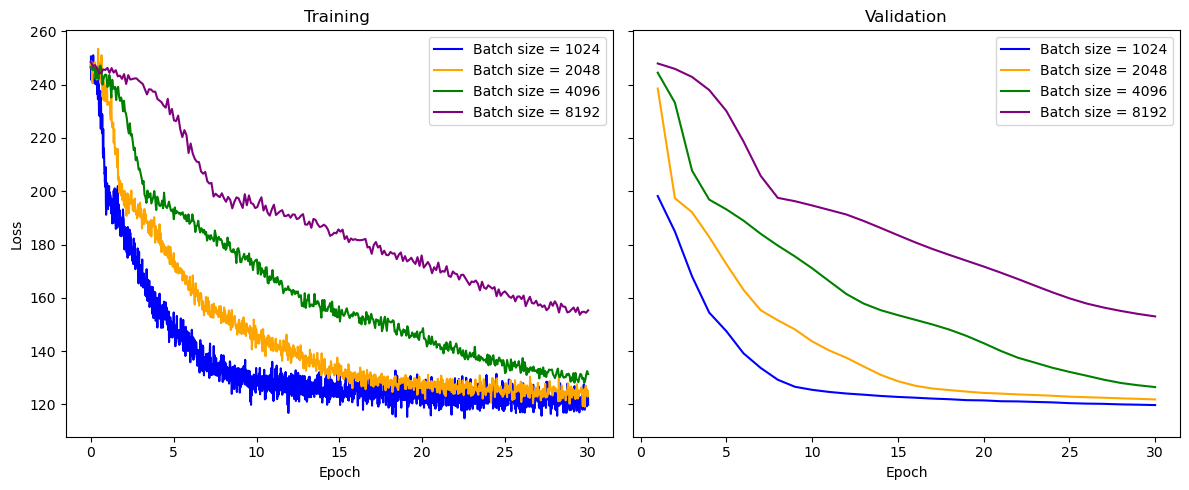

In [55]:
draw_losses(["bz1024", "nl-4", "bz4096", "bz8192"], ["Batch size = 1024", "Batch size = 2048", "Batch size = 4096", "Batch size = 8192"])

We can see if we increase the batch size the learning is slower. I was not expecting this because I thought that if the batch size is bigger then the average gradient should be more close to the real gradient of all the train data, so it should moves faster to the minimun

You're done, yay!

A couple of final notes on that last problem:
1. I just mentioned a few of the standard loss functions implemented in PyTorch, but you can implement _custom_ loss functions as well! They're subclasses of `torch.nn.Module`, just like the models themselves. This, along with model architecture, is one of the biggest "knobs" that researchers play with to improve model training (check out [multi-objective optimization](https://indico.cern.ch/event/1299889/contributions/5465272/attachments/2773733/4833542/MDMM%20lecture.pdf) for some cool stuff in this arena).
2. This last problem was likely your first stumbling steps towards the practice of _hyperparameter optimization_. This is a big deal in machine learning, and doing it systematically is often a large effort (and large computational cost) for ML-based research projects. One package that exists to ease the effort is [Optuna](https://optuna.readthedocs.io/en/stable/), a very flexible framework for general optimization problems. I've used it a lot in the past, and it greatly simplifies the process of finding good hyperparameters amidst a huge search space.